# JURISIGHT — Interpretable Legal Document Classification & Verdict Prediction

**A Transformer-based NLP system with Explainable AI (XAI) for ECHR case analysis**

This notebook implements a complete pipeline for:
1. **Data Preprocessing** — Loading & cleaning the ECHR dataset from LexGLUE
2. **Model Training** — Fine-tuning BERT, RoBERTa, and Legal-BERT
3. **Evaluation & Comparison** — Comprehensive metrics, confusion matrices, ROC curves, fairness analysis
4. **Explainable AI (XAI)** — SHAP, LIME, Captum Integrated Gradients, Attention Visualization, Occlusion
5. **Web Application** — Flask API + HTML/CSS/JS frontend for interactive predictions

##  Environment Setup

### Install Dependencies

In [1]:
!pip install -q transformers datasets tokenizers torch scikit-learn pandas numpy matplotlib seaborn tqdm shap lime captum flask flask-cors pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.4 MB/s eta 0:00:00


### Mount Google Drive (for model persistence)

In [2]:
# === CELL: Mount Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

DRIVE_SAVE_DIR = "/content/drive/MyDrive/Jurisight_Models"
import os
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
print(f"✅ Google Drive mounted. Models will be saved to: {DRIVE_SAVE_DIR}")


Mounted at /content/drive
✅ Google Drive mounted. Models will be saved to: /content/drive/MyDrive/Jurisight_Models


### Import Libraries

In [3]:
import os, sys, json, re, time, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm
from IPython.display import display, HTML

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from datasets import load_dataset
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from sklearn.metrics import (
    classification_report, confusion_matrix, multilabel_confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score,
    hamming_loss, roc_auc_score, roc_curve,
)
from sklearn.preprocessing import MultiLabelBinarizer

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🖥️ Device: cuda
   GPU: Tesla T4


---
##  Configuration

Define all hyperparameters, dataset config, model names, and directory paths.

In [4]:
class Config:
    DATASET_NAME = "lex_glue"
    DATASET_CONFIG = "ecthr_a"
    MAX_SEQ_LENGTH = 512

    ARTICLE_LABELS = [
        "Art. 2 - Right to life", "Art. 3 - Prohibition of torture",
        "Art. 5 - Right to liberty/security", "Art. 6 - Right to a fair trial",
        "Art. 8 - Private/family life", "Art. 9 - Freedom of thought",
        "Art. 10 - Freedom of expression", "Art. 11 - Freedom of assembly",
        "Art. 14 - Prohibition of discrimination", "Art. P1-1 - Protection of property",
    ]
    ARTICLE_SHORT = [l.split(" - ")[0] for l in ARTICLE_LABELS]
    NUM_LABELS = 10

    MODEL_NAMES = {
        "bert": "bert-base-uncased",
        "roberta": "roberta-base",
        "legal-bert": "nlpaueb/legal-bert-base-uncased",
    }

    DATA_DIR = "/content/jurisight_data"
    MODEL_DIR = "/content/jurisight_models"
    OUTPUT_DIR = "/content/jurisight_outputs"

    BATCH_SIZE = 16
    NUM_EPOCHS = 5
    LEARNING_RATE = 2e-5
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    MAX_GRAD_NORM = 1.0
    PATIENCE = 3
    SEED = 42

config = Config()
torch.manual_seed(config.SEED)
np.random.seed(config.SEED)
for d in [config.DATA_DIR, config.MODEL_DIR, config.OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)
print("✅ Config ready")

✅ Config ready


### Model Architecture & Dataset Classes

`ECHRClassifier`: Transformer encoder → dropout → 256-dim hidden → dropout → 10-label output  
`ECHRDataset`: PyTorch Dataset wrapper for tokenized inputs  
`predict_text()`: Helper for single-text inference

In [5]:
class ECHRClassifier(nn.Module):
    """Multi-label classifier: Transformer encoder → classifier head."""
    def __init__(self, model_name, num_labels, dropout_rate=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate), nn.Linear(h, 256), nn.ReLU(),
            nn.Dropout(dropout_rate), nn.Linear(256, num_labels),
        )
        self.model_name = model_name
        self.num_labels = num_labels

    def forward(self, input_ids, attention_mask, labels=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
        logits = self.classifier(out.last_hidden_state[:, 0, :])
        result = {"logits": logits, "attentions": out.attentions}
        if labels is not None:
            result["loss"] = nn.BCEWithLogitsLoss()(logits, labels)
        return result

class ECHRDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels
    def __len__(self): return len(self.input_ids)
    def __getitem__(self, idx):
        return {"input_ids": self.input_ids[idx],
                "attention_mask": self.attention_mask[idx],
                "labels": self.labels[idx]}

def predict_text(text, model, tokenizer, device, max_length=512):
    """Helper: predict ECHR violations for a text string."""
    inputs = tokenizer(text, return_tensors="pt", max_length=max_length,
                       truncation=True, padding="max_length")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(inputs["input_ids"], inputs["attention_mask"])
    logits = outputs["logits"].cpu().numpy()[0]
    probs = 1 / (1 + np.exp(-logits))
    return probs, (probs > 0.5).astype(int), outputs

print("✅ Classes defined")

✅ Classes defined


---
##  Part 1: Data Preprocessing

Load the ECHR dataset (`lex_glue/ecthr_a`), clean legal text, tokenize for all three models.

### 1.1 Load ECHR Dataset

In [6]:
print("📥 Loading ECHR dataset...")
dataset = load_dataset(config.DATASET_NAME, config.DATASET_CONFIG)
for split, data in dataset.items():
    print(f"  {split}: {len(data)} samples")

📥 Loading ECHR dataset...


README.md: 0.00B [00:00, ?B/s]

ecthr_a/train-00000-of-00001.parquet:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

ecthr_a/test-00000-of-00001.parquet:   0%|          | 0.00/5.68M [00:00<?, ?B/s]

ecthr_a/validation-00000-of-00001.parque(…):   0%|          | 0.00/5.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

  train: 9000 samples
  test: 1000 samples
  validation: 1000 samples


### 1.2 Dataset Exploration

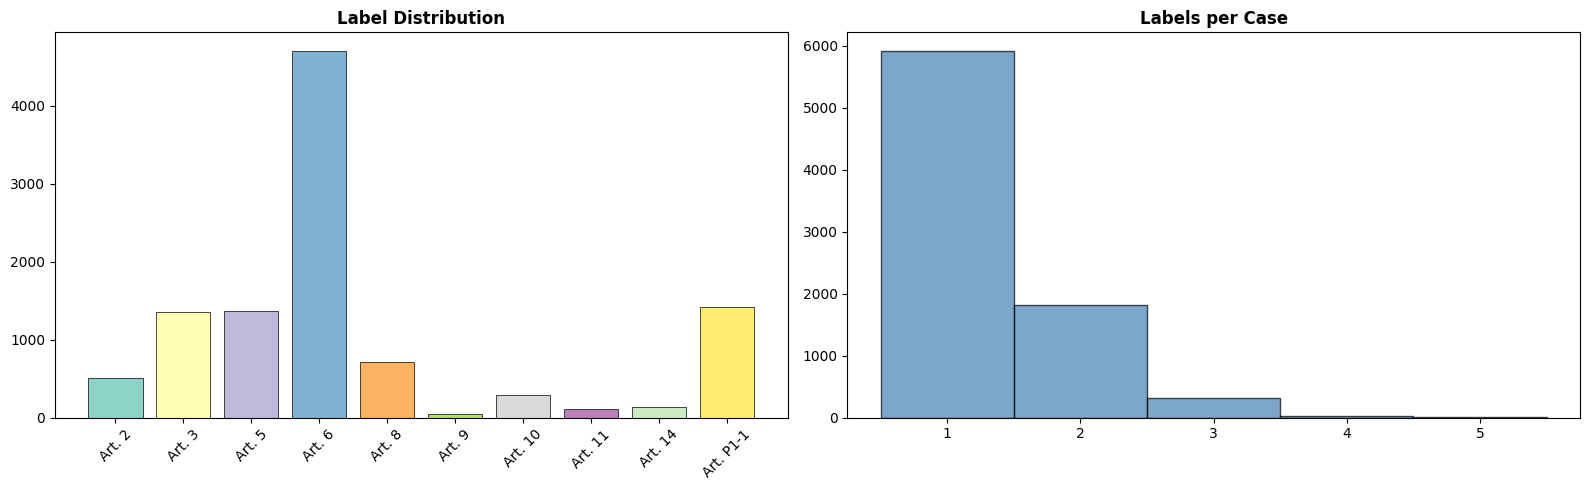

In [7]:
train_data = dataset["train"]
all_labels = []
for item in train_data:
    all_labels.extend(item["labels"])
label_counts = Counter(all_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
counts = [label_counts.get(i, 0) for i in range(config.NUM_LABELS)]
axes[0].bar(config.ARTICLE_SHORT, counts, color=plt.cm.Set3(np.linspace(0,1,10)), edgecolor="black", linewidth=0.5)
axes[0].set_title("Label Distribution", fontweight="bold"); axes[0].tick_params(axis="x", rotation=45)
labels_per = [len(item["labels"]) for item in train_data]
axes[1].hist(labels_per, bins=range(1, max(labels_per)+2), color="steelblue", edgecolor="black", alpha=0.7, align="left")
axes[1].set_title("Labels per Case", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/dataset_exploration.png", dpi=150); plt.show()

### 1.3 Text Preprocessing

In [8]:
def clean_legal_text(paragraphs):
    text = " ".join(paragraphs)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'^\d+\.\s*', '', text)
    text = re.sub(r'\s\d+\.\s', ' ', text)
    return text

def preprocess_split(split):
    texts = [clean_legal_text(item["text"]) for item in tqdm(split, desc="Cleaning")]
    mlb = MultiLabelBinarizer(classes=list(range(config.NUM_LABELS)))
    labels = mlb.fit_transform([item["labels"] for item in split]).tolist()
    return texts, labels

print("🧹 Preprocessing...")
train_texts, train_labels = preprocess_split(dataset["train"])
val_texts, val_labels = preprocess_split(dataset["validation"])
test_texts, test_labels = preprocess_split(dataset["test"])
print(f"✅ Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

# Save raw text for XAI later
with open(f"{config.DATA_DIR}/test_processed.json", "w") as f:
    json.dump({"text": test_texts, "labels": test_labels}, f)

🧹 Preprocessing...


Cleaning:   0%|          | 0/9000 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/1000 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/1000 [00:00<?, ?it/s]

✅ Train: 9000, Val: 1000, Test: 1000


### 1.4 Tokenization (BERT, RoBERTa, Legal-BERT)

In [9]:
print("🔤 Tokenizing for all models...")
tokenizers = {}
tokenized_data = {}

for model_key, model_name in config.MODEL_NAMES.items():
    print(f"  Tokenizing for {model_key}...")
    tok = AutoTokenizer.from_pretrained(model_name)
    tokenizers[model_key] = tok
    tokenized_data[model_key] = {}
    for split_name, texts, labels in [("train", train_texts, train_labels),
                                       ("val", val_texts, val_labels),
                                       ("test", test_texts, test_labels)]:
        enc = tok(texts, max_length=config.MAX_SEQ_LENGTH, truncation=True,
                  padding="max_length", return_tensors="pt")
        tokenized_data[model_key][split_name] = ECHRDataset(
            enc["input_ids"], enc["attention_mask"],
            torch.tensor(labels, dtype=torch.float32))

print("✅ Part 1 complete — data ready")

🔤 Tokenizing for all models...
  Tokenizing for bert...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Part 1 complete — data ready


---
##  Part 2: Model Training

Fine-tune all three Transformer models with AdamW optimizer, linear warmup, and early stopping based on validation Micro-F1.



### 2.1 Training & Evaluation Functions

In [10]:
def train_one_epoch(model, loader, optimizer, scheduler, device):
    model.train(); total_loss = 0; all_p = []; all_l = []
    for batch in tqdm(loader, desc="Train", leave=False):
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labs = batch["labels"].to(device)
        optimizer.zero_grad()
        out = model(ids, mask, labs)
        out["loss"].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.MAX_GRAD_NORM)
        optimizer.step(); scheduler.step()
        total_loss += out["loss"].item()
        preds = (torch.sigmoid(out["logits"]).cpu().detach().numpy() > 0.5).astype(int)
        all_p.extend(preds); all_l.extend(labs.cpu().numpy().astype(int))
    all_p, all_l = np.array(all_p), np.array(all_l)
    return total_loss/len(loader), f1_score(all_l, all_p, average="micro", zero_division=0), f1_score(all_l, all_p, average="macro", zero_division=0)

def evaluate_model(model, loader, device):
    model.eval(); total_loss = 0; all_p = []; all_l = []; all_prob = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval", leave=False):
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labs = batch["labels"].to(device)
            out = model(ids, mask, labs)
            total_loss += out["loss"].item()
            probs = torch.sigmoid(out["logits"]).cpu().numpy()
            all_prob.extend(probs)
            all_p.extend((probs > 0.5).astype(int))
            all_l.extend(labs.cpu().numpy().astype(int))
    all_p, all_l, all_prob = np.array(all_p), np.array(all_l), np.array(all_prob)
    return {"loss": total_loss/len(loader),
            "micro_f1": f1_score(all_l, all_p, average="micro", zero_division=0),
            "macro_f1": f1_score(all_l, all_p, average="macro", zero_division=0),
            "preds": all_p, "labels": all_l, "probs": all_prob}


### 2.2 Train All Models

In [ ]:
trained_models = {}
training_histories = {}
best_scores = {}

for model_key, model_name in config.MODEL_NAMES.items():
    print(f"\n{'='*60}\n🚀 Training: {model_key.upper()} ({model_name})\n{'='*60}")
    model = ECHRClassifier(model_name, config.NUM_LABELS).to(device)
    train_loader = DataLoader(tokenized_data[model_key]["train"], batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(tokenized_data[model_key]["val"], batch_size=config.BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)
    total_steps = len(train_loader) * config.NUM_EPOCHS
    optimizer = AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * config.WARMUP_RATIO), total_steps)

    best_f1 = 0; best_state = None; patience = 0
    history = {"train_loss":[], "val_loss":[], "train_f1":[], "val_f1":[], "train_macro_f1":[], "val_macro_f1":[]}

    for epoch in range(config.NUM_EPOCHS):
        t_loss, t_mic, t_mac = train_one_epoch(model, train_loader, optimizer, scheduler, device)
        v = evaluate_model(model, val_loader, device)
        for k, val in [("train_loss",t_loss),("val_loss",v["loss"]),("train_f1",t_mic),("val_f1",v["micro_f1"]),("train_macro_f1",t_mac),("val_macro_f1",v["macro_f1"])]:
            history[k].append(val)
        print(f"  Ep {epoch+1}: Train F1={t_mic:.4f} | Val F1={v['micro_f1']:.4f}")
        if v["micro_f1"] > best_f1:
            best_f1 = v["micro_f1"]; best_state = copy.deepcopy(model.state_dict()); patience = 0
            print(f"  ⭐ New best!")
        else:
            patience += 1
            if patience >= config.PATIENCE:
                print(f"  🛑 Early stopping"); break

    model.load_state_dict(best_state)
    save_dir = f"{config.MODEL_DIR}/{model_key}"
    os.makedirs(save_dir, exist_ok=True)
    torch.save({"model_state_dict": best_state, "model_name": model_name,
                "num_labels": config.NUM_LABELS, "best_val_f1": best_f1, "history": history},
               f"{save_dir}/best_model.pt")
    tokenizers[model_key].save_pretrained(save_dir)
    trained_models[model_key] = model
    training_histories[model_key] = history
    best_scores[model_key] = best_f1
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("\n📊 Training Summary:")
for k, s in best_scores.items(): print(f"  {k.upper()}: {s:.4f}")

### 2.3 Training Curves

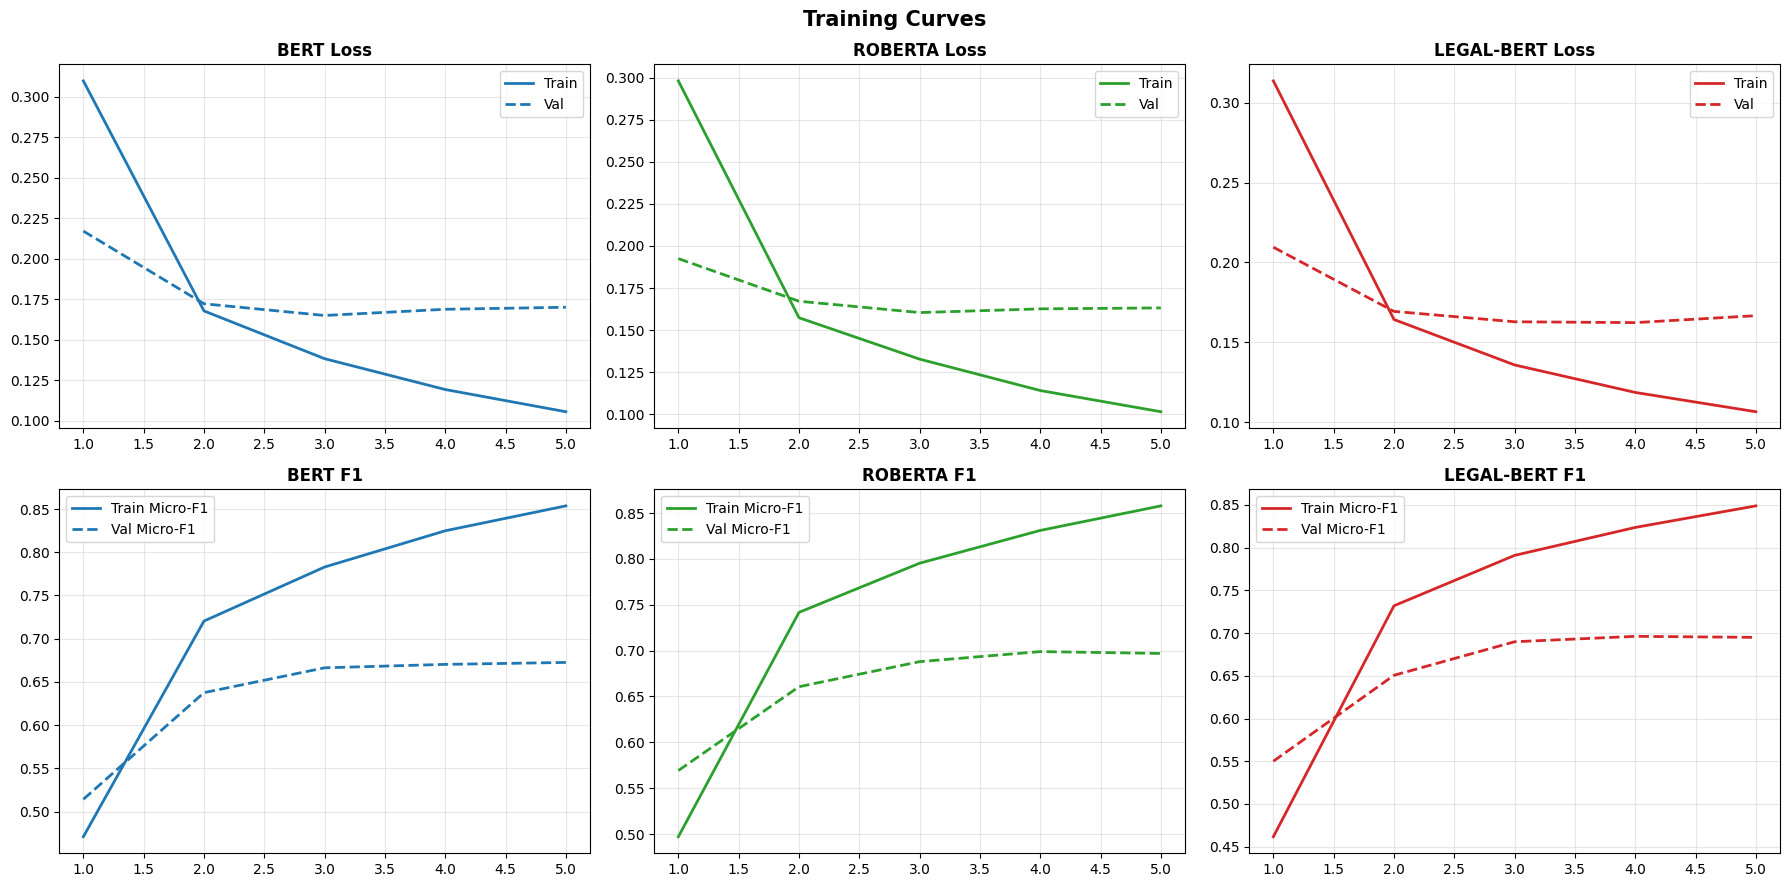

✅ Part 2 complete — models trained


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
colors = {"bert": "#1f77b4", "roberta": "#2ca02c", "legal-bert": "#d62728"}
for i, mk in enumerate(config.MODEL_NAMES):
    h = training_histories[mk]; epochs = range(1, len(h["train_loss"])+1); c = colors[mk]
    axes[0][i].plot(epochs, h["train_loss"], c=c, lw=2, label="Train")
    axes[0][i].plot(epochs, h["val_loss"], c=c, lw=2, ls="--", label="Val")
    axes[0][i].set_title(f"{mk.upper()} Loss", fontweight="bold"); axes[0][i].legend(); axes[0][i].grid(alpha=0.3)
    axes[1][i].plot(epochs, h["train_f1"], c=c, lw=2, label="Train Micro-F1")
    axes[1][i].plot(epochs, h["val_f1"], c=c, lw=2, ls="--", label="Val Micro-F1")
    axes[1][i].set_title(f"{mk.upper()} F1", fontweight="bold"); axes[1][i].legend(); axes[1][i].grid(alpha=0.3)
plt.suptitle("Training Curves", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/training_curves.png", dpi=150); plt.show()


### 2.4 Save Models to Google Drive

In [ ]:
# === CELL: Save Trained Models to Google Drive ===
import shutil

for model_key in config.MODEL_NAMES:
    src = f"{config.MODEL_DIR}/{model_key}"
    dst = f"{DRIVE_SAVE_DIR}/{model_key}"
    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"✅ Saved {model_key} to Google Drive")

# Also save comparison CSV and fairness results later
print("🎉 All models saved to Google Drive!")

print("✅ Part 2 complete — models trained")

---
###  "Alternative": Load Pre-trained Models from Google Drive

 
It loads saved checkpoints from Google Drive and prepares the data for evaluation.

In [11]:

from google.colab import drive
drive.mount('/content/drive')
DRIVE_SAVE_DIR = "/content/drive/MyDrive/Jurisight_Models"

import shutil

# Copy models from Drive to local storage (faster inference)
for model_key in config.MODEL_NAMES:
    src = f"{DRIVE_SAVE_DIR}/{model_key}"
    dst = f"{config.MODEL_DIR}/{model_key}"
    if os.path.exists(src):
        os.makedirs(dst, exist_ok=True)
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"✅ Loaded {model_key} from Google Drive")

# Reload models into memory
trained_models = {}
tokenizers = {}
for model_key, model_name in config.MODEL_NAMES.items():
    checkpoint = torch.load(
        f"{config.MODEL_DIR}/{model_key}/best_model.pt",
        map_location=device, weights_only=False
    )
    model = ECHRClassifier(checkpoint["model_name"], checkpoint["num_labels"])
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    trained_models[model_key] = model
    tokenizers[model_key] = AutoTokenizer.from_pretrained(checkpoint["model_name"])
    print(f"  📦 {model_key}: Val F1 = {checkpoint.get('best_val_f1', 'N/A')}")

# Still need to load/preprocess data for evaluation
print("\n📥 Loading ECHR dataset...")
dataset = load_dataset(config.DATASET_NAME, config.DATASET_CONFIG)

train_texts, train_labels = preprocess_split(dataset["train"])
val_texts, val_labels = preprocess_split(dataset["validation"])
test_texts, test_labels = preprocess_split(dataset["test"])

with open(f"{config.DATA_DIR}/test_processed.json", "w") as f:
    json.dump({"text": test_texts, "labels": test_labels}, f)

tokenized_data = {}
for model_key, model_name in config.MODEL_NAMES.items():
    tok = tokenizers[model_key]
    tokenized_data[model_key] = {}
    for split_name, texts, labels in [("train", train_texts, train_labels),
                                       ("val", val_texts, val_labels),
                                       ("test", test_texts, test_labels)]:
        enc = tok(texts, max_length=config.MAX_SEQ_LENGTH, truncation=True,
                  padding="max_length", return_tensors="pt")
        tokenized_data[model_key][split_name] = ECHRDataset(
            enc["input_ids"], enc["attention_mask"],
            torch.tensor(labels, dtype=torch.float32))

print("✅ Models loaded from Drive + data ready.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded bert from Google Drive
✅ Loaded roberta from Google Drive
✅ Loaded legal-bert from Google Drive


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  📦 bert: Val F1 = 0.6725490196078432


...

  📦 legal-bert: Val F1 = 0.6962524654832347

📥 Loading ECHR dataset...


Cleaning:   0%|          | 0/9000 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/1000 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/1000 [00:00<?, ?it/s]

✅ Models loaded from Drive + data ready.


---
##  Part 3: Evaluation & Model Comparison

Evaluate all models on the test set with comprehensive metrics.

### 3.1 Test Set Evaluation

In [12]:
print("📊 Evaluating on test set...")
test_results = {}
for mk in config.MODEL_NAMES:
    loader = DataLoader(tokenized_data[mk]["test"], batch_size=config.BATCH_SIZE*2, shuffle=False)
    r = evaluate_model(trained_models[mk], loader, device)
    test_results[mk] = {"labels": r["labels"], "preds": r["preds"], "probs": r["probs"]}
    print(f"  {mk.upper()}: Micro-F1={r['micro_f1']:.4f}, Macro-F1={r['macro_f1']:.4f}")


📊 Evaluating on test set...


Eval:   0%|          | 0/32 [00:00<?, ?it/s]

`sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.


  BERT: Micro-F1=0.6631, Macro-F1=0.5112


Eval:   0%|          | 0/32 [00:00<?, ?it/s]

  ROBERTA: Micro-F1=0.6808, Macro-F1=0.5350


Eval:   0%|          | 0/32 [00:00<?, ?it/s]

  LEGAL-BERT: Micro-F1=0.6779, Macro-F1=0.5303


### 3.2 Comparison Table

In [13]:
rows = []
for mk in config.MODEL_NAMES:
    l, p, pr = test_results[mk]["labels"], test_results[mk]["preds"], test_results[mk]["probs"]
    row = {"Model": mk.upper(),
           "Micro-F1": f1_score(l, p, average="micro", zero_division=0),
           "Macro-F1": f1_score(l, p, average="macro", zero_division=0),
           "Precision": precision_score(l, p, average="micro", zero_division=0),
           "Recall": recall_score(l, p, average="micro", zero_division=0),
           "Hamming Loss": hamming_loss(l, p),
           "Subset Acc": accuracy_score(l, p)}
    try: row["ROC-AUC"] = roc_auc_score(l, pr, average="macro")
    except: row["ROC-AUC"] = np.nan
    rows.append(row)
comparison_df = pd.DataFrame(rows)
print("\n📋 Model Comparison:")
print(comparison_df.to_string(index=False, float_format="%.4f"))
comparison_df.to_csv(f"{config.OUTPUT_DIR}/model_comparison.csv", index=False)


📋 Model Comparison:
     Model  Micro-F1  Macro-F1  Precision  Recall  Hamming Loss  Subset Acc  ROC-AUC
      BERT    0.6631    0.5112     0.7099  0.6220        0.0689      0.5100   0.8946
   ROBERTA    0.6808    0.5350     0.7163  0.6486        0.0663      0.5150   0.9053
LEGAL-BERT    0.6779    0.5303     0.7371  0.6275        0.0650      0.5320   0.8806


### 3.3 Confusion Matrices

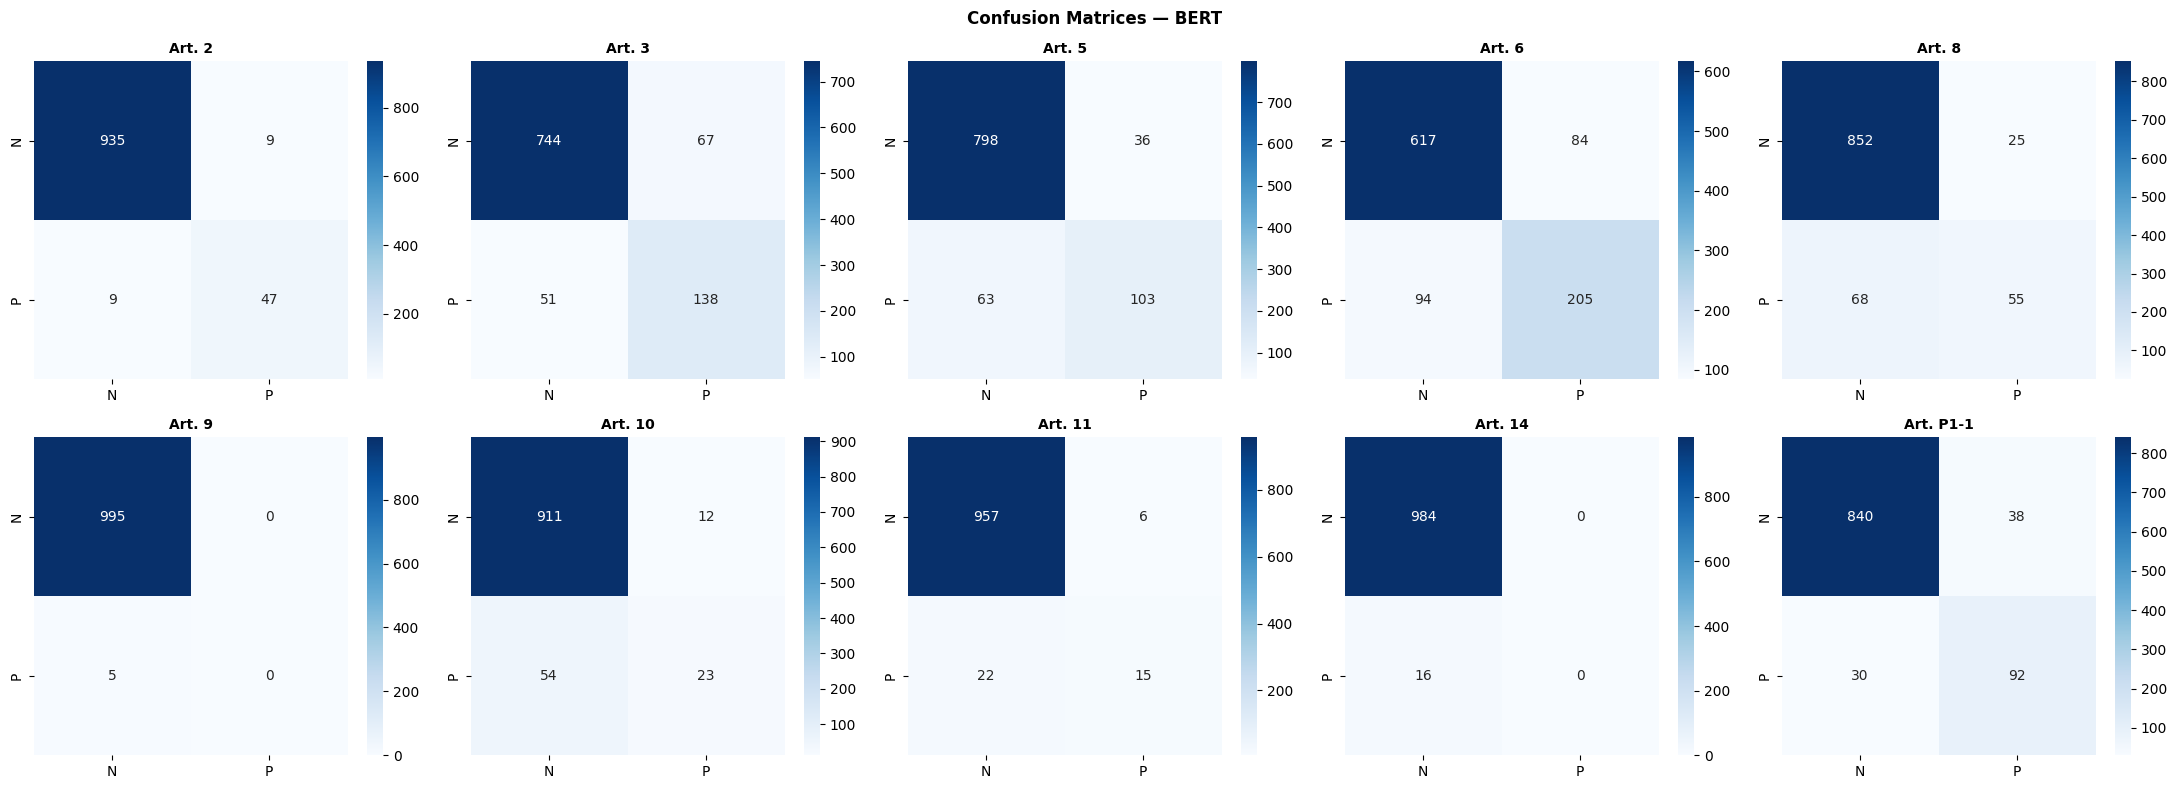

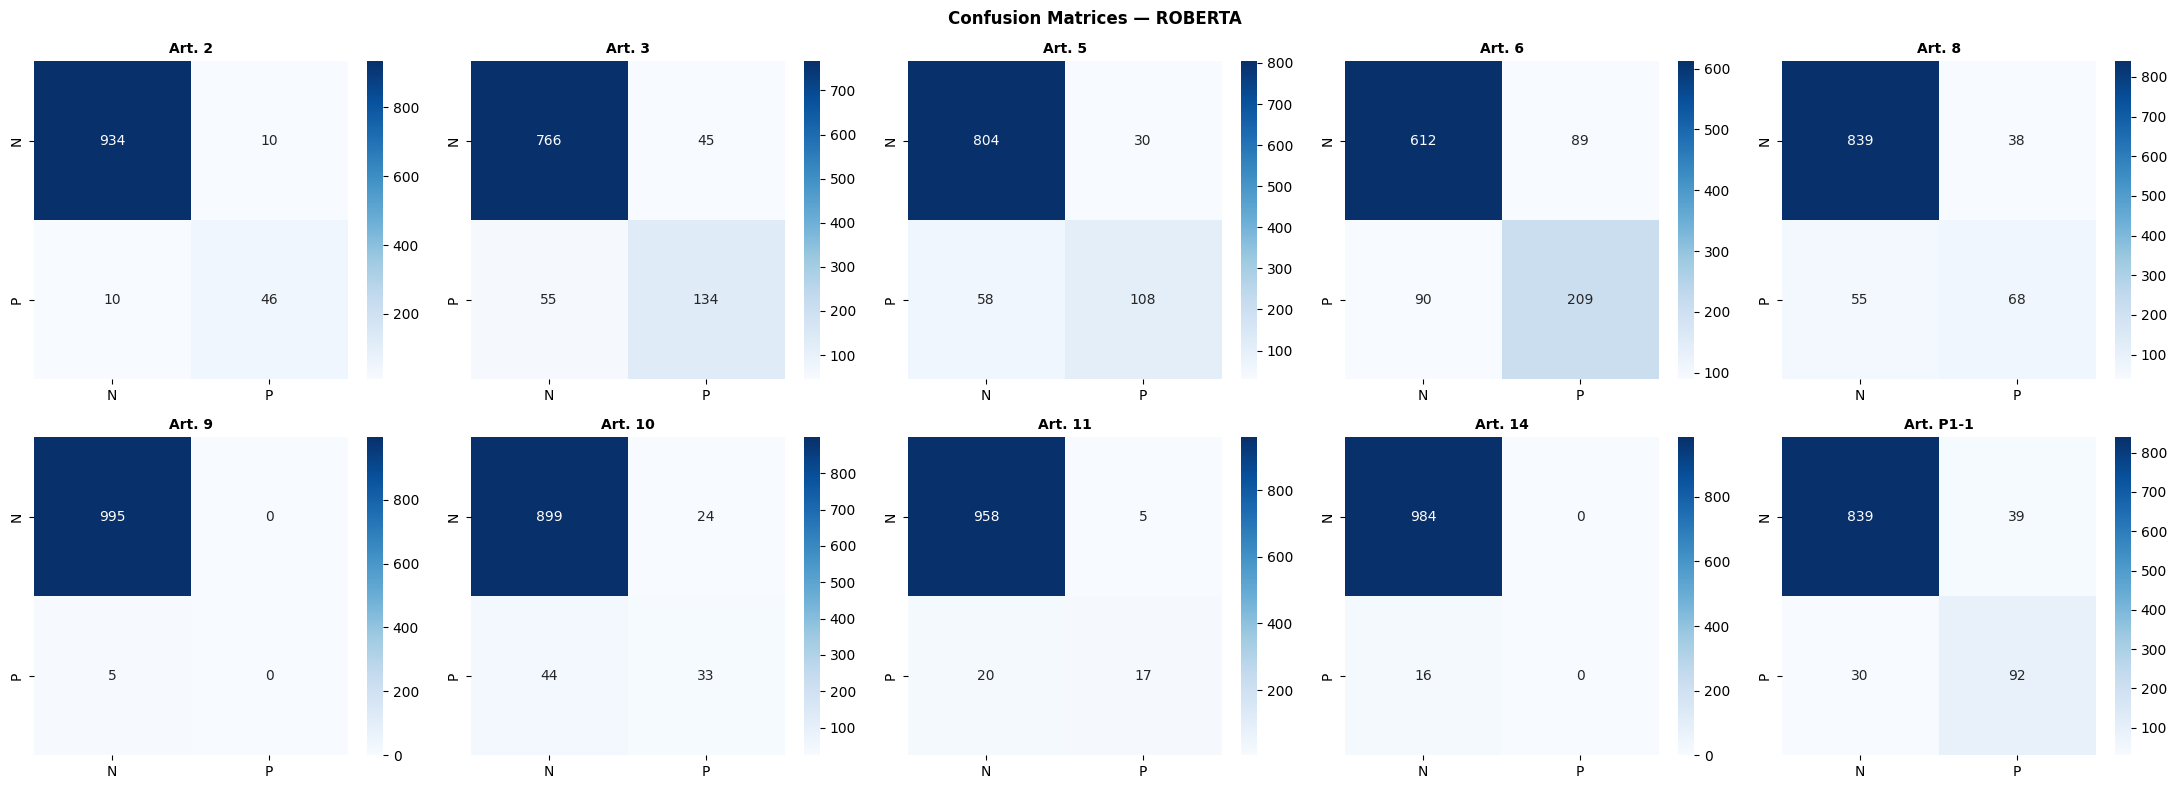

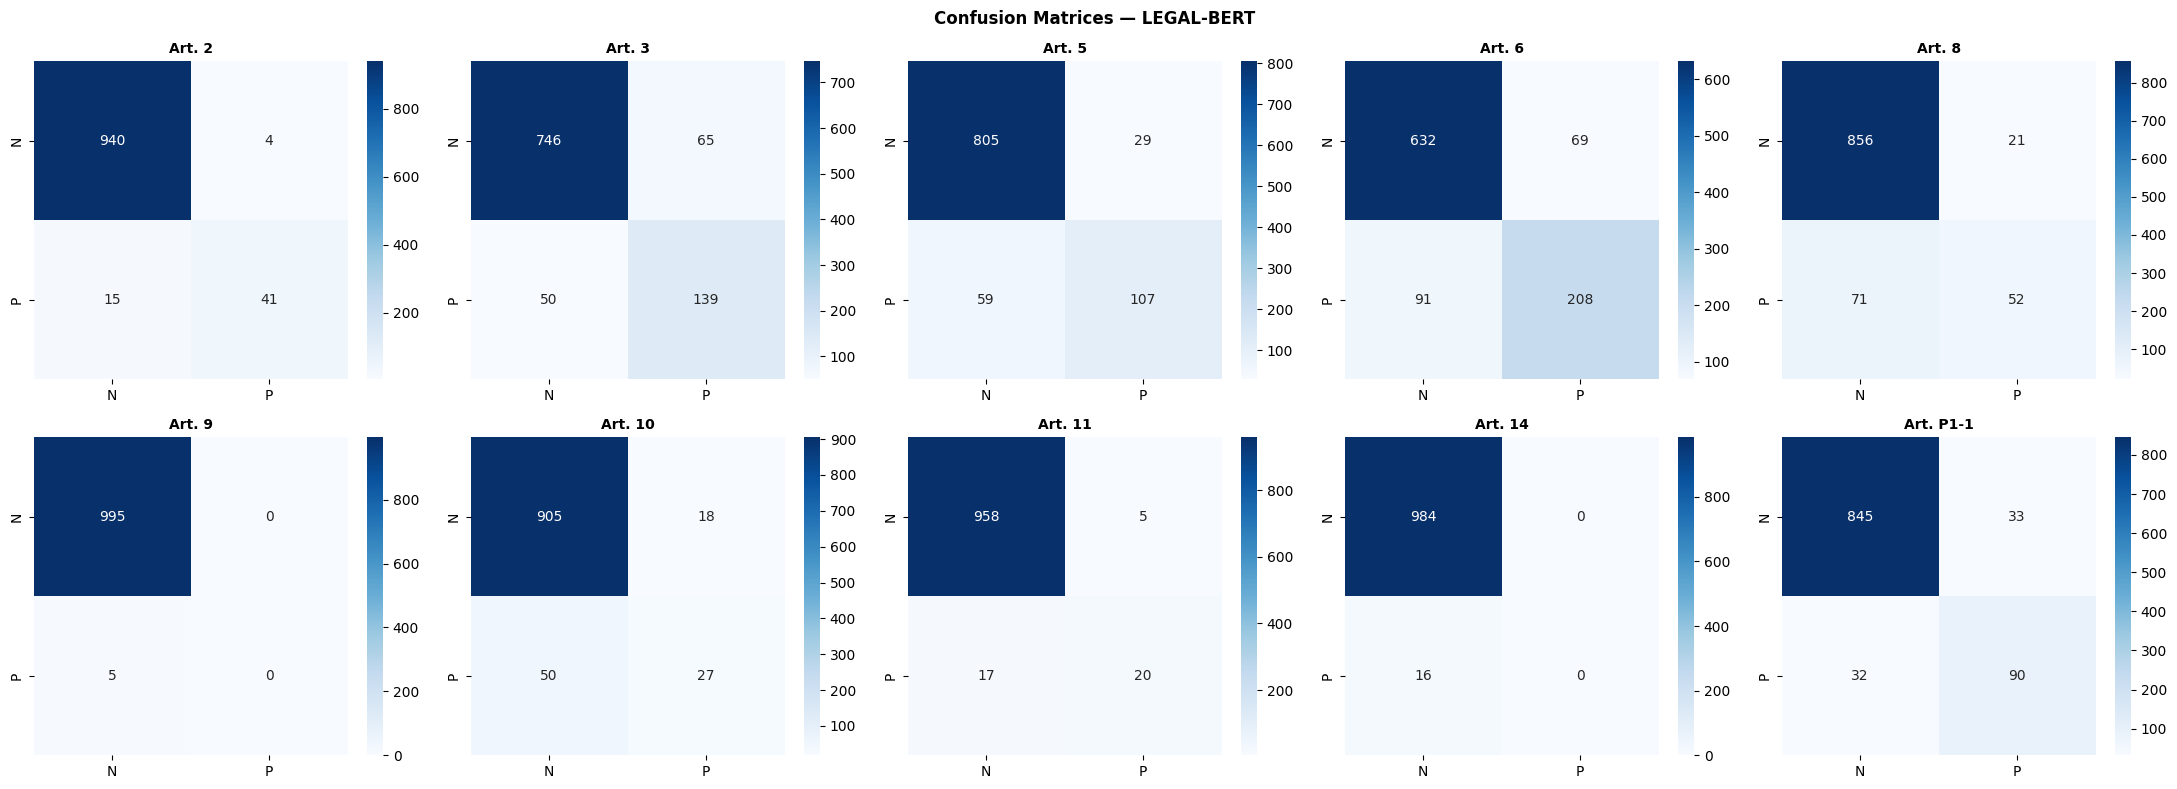

In [14]:
for mk in config.MODEL_NAMES:
    l, p = test_results[mk]["labels"], test_results[mk]["preds"]
    mcm = multilabel_confusion_matrix(l, p)
    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    for i, (cm, ax) in enumerate(zip(mcm, axes.flatten())):
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=["N","P"], yticklabels=["N","P"])
        ax.set_title(config.ARTICLE_SHORT[i], fontsize=10, fontweight="bold")
    plt.suptitle(f"Confusion Matrices — {mk.upper()}", fontweight="bold")
    plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/cm_{mk}.png", dpi=150); plt.show()

### 3.4 ROC Curves

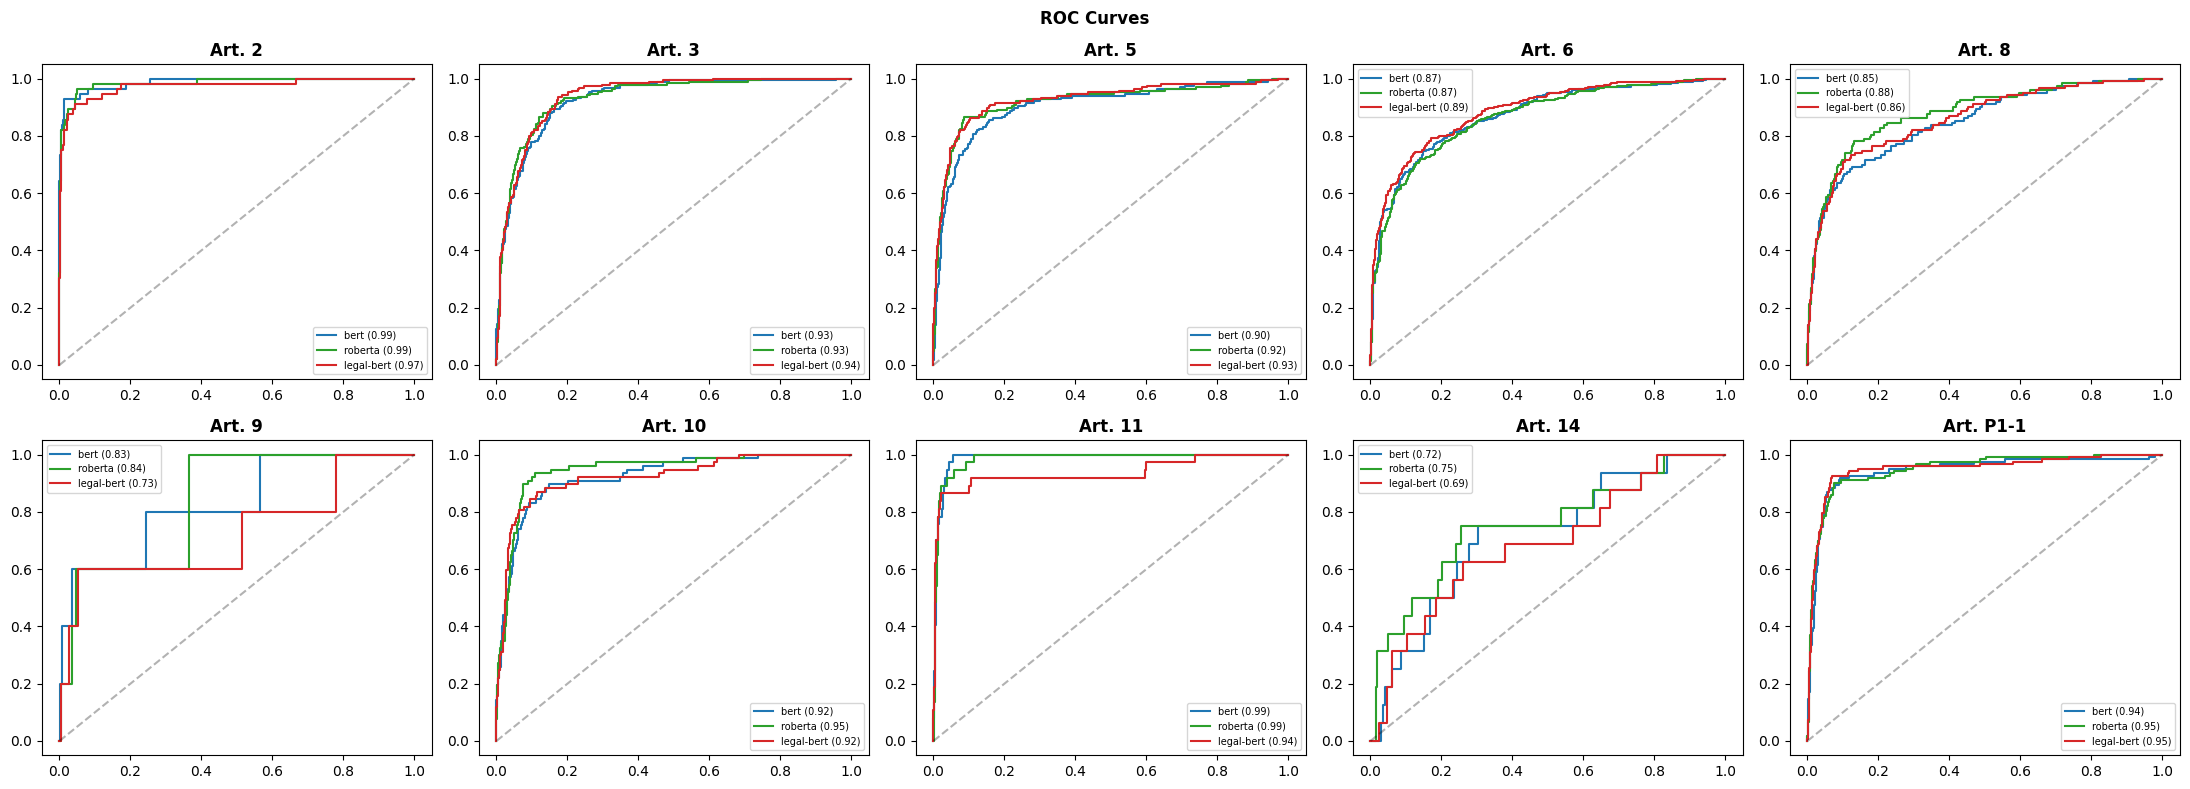

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
clr = {"bert":"#1f77b4","roberta":"#2ca02c","legal-bert":"#d62728"}
for i, ax in enumerate(axes.flatten()):
    for mk in config.MODEL_NAMES:
        lc = test_results[mk]["labels"][:, i]; pc = test_results[mk]["probs"][:, i]
        if len(np.unique(lc)) < 2: continue
        fpr, tpr, _ = roc_curve(lc, pc)
        auc = roc_auc_score(lc, pc)
        ax.plot(fpr, tpr, color=clr[mk], label=f"{mk} ({auc:.2f})", lw=1.5)
    ax.plot([0,1],[0,1],'k--',alpha=0.3); ax.set_title(config.ARTICLE_SHORT[i], fontweight="bold")
    ax.legend(fontsize=7)
plt.suptitle("ROC Curves", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/roc_curves.png", dpi=150); plt.show()


### 3.5 Fairness Analysis


⚖️ Fairness Analysis:
  BERT: F1 StdDev=0.2805, Range=0.8393
  ROBERTA: F1 StdDev=0.2818, Range=0.8214
  LEGAL-BERT: F1 StdDev=0.2836, Range=0.8119


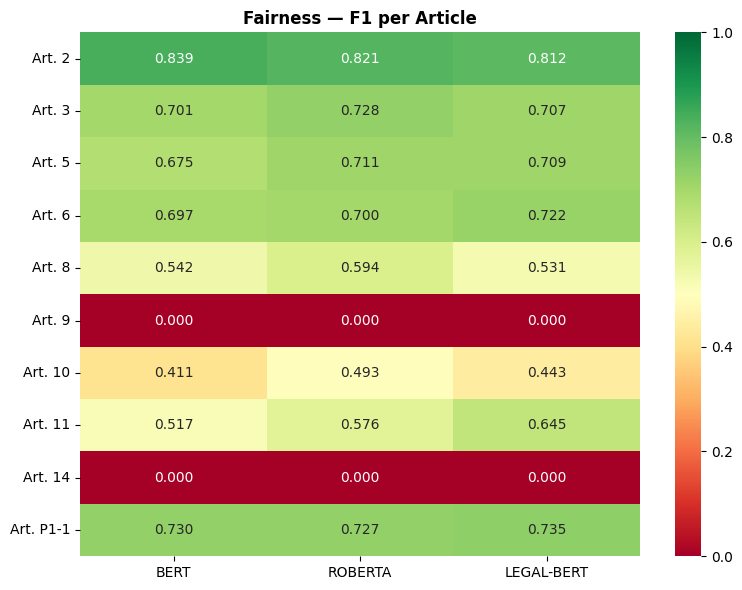

✅ Part 3 complete — evaluation done


In [16]:
print("\n⚖️ Fairness Analysis:")
fairness_results = {}
for mk in config.MODEL_NAMES:
    l, p = test_results[mk]["labels"], test_results[mk]["preds"]
    f1s = [f1_score(l[:,i], p[:,i], zero_division=0) for i in range(config.NUM_LABELS)]
    print(f"  {mk.upper()}: F1 StdDev={np.std(f1s):.4f}, Range={max(f1s)-min(f1s):.4f}")
    fairness_results[mk] = {config.ARTICLE_SHORT[i]: {"F1": f1s[i], "Support": int(l[:,i].sum())} for i in range(config.NUM_LABELS)}

# Heatmap
data = {mk.upper(): [fairness_results[mk][a]["F1"] for a in config.ARTICLE_SHORT] for mk in config.MODEL_NAMES}
df_fair = pd.DataFrame(data, index=config.ARTICLE_SHORT)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_fair, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax)
ax.set_title("Fairness — F1 per Article", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/fairness_heatmap.png", dpi=150); plt.show()

with open(f"{config.OUTPUT_DIR}/fairness_results.json", "w") as f:
    json.dump({mk: {k: {kk: float(vv) for kk,vv in v.items()} for k,v in cls.items()} for mk, cls in fairness_results.items()}, f, indent=2)

print("✅ Part 3 complete — evaluation done")

---
##  Part 4: Explainable AI (XAI)

Apply multiple XAI techniques to understand model predictions:
- **SHAP-style** — Perturbation-based word importance
- **LIME** — Local interpretable model-agnostic explanations
- **Captum** — Integrated Gradients (gradient-based attribution)
- **Attention** — Transformer attention weight visualization
- **Occlusion** — Sentence-level importance analysis

### 4.1 XAI Setup

In [17]:
import shap
import lime
import lime.lime_text
from captum.attr import IntegratedGradients

os.makedirs(f"{config.OUTPUT_DIR}/xai", exist_ok=True)

# Use the best model for XAI (change if needed)
xai_model_key = "legal-bert"
xai_model = trained_models[xai_model_key]
xai_tokenizer = tokenizers[xai_model_key]

# Load test text samples
with open(f"{config.DATA_DIR}/test_processed.json") as f:
    test_raw = json.load(f)

print(f" Using {xai_model_key} for XAI. Test samples: {len(test_raw['text'])}")

 Using legal-bert for XAI. Test samples: 1000


### 4.2 SHAP-style Feature Importance


📊 SHAP-style Feature Importance (Perturbation-based)


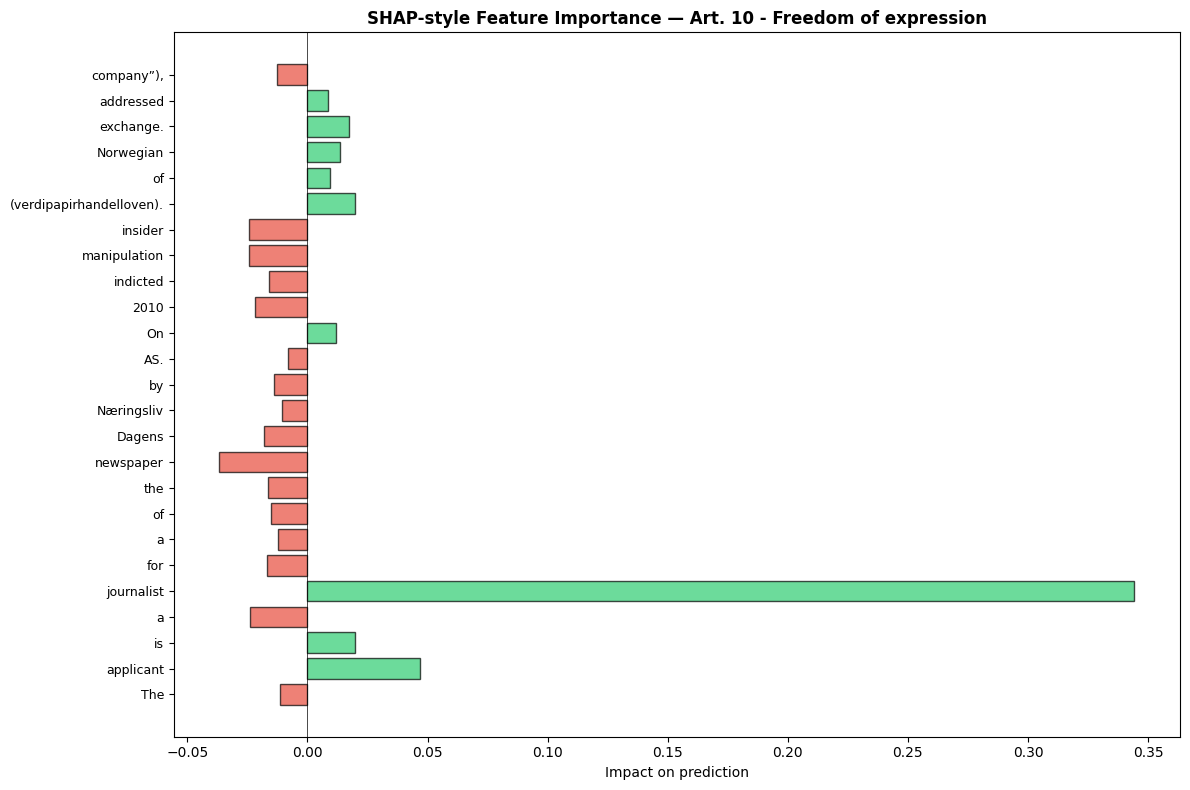

✅ SHAP-style analysis done


In [18]:
print("\n📊 SHAP-style Feature Importance (Perturbation-based)")
sample_text = test_raw["text"][0]

def shap_perturbation(text, model, tokenizer, device, config, n_words=100):
    """Remove each word and measure prediction drop."""
    words = text.split()[:n_words]
    base_probs, _, _ = predict_text(" ".join(words), model, tokenizer, device)
    target = np.argmax(base_probs)
    importances = []
    for i in range(len(words)):
        masked = words[:i] + words[i+1:]
        m_probs, _, _ = predict_text(" ".join(masked), model, tokenizer, device)
        importances.append(base_probs[target] - m_probs[target])
    return words, np.array(importances), target

words, imp, target_art = shap_perturbation(sample_text, xai_model, xai_tokenizer, device, config)

top_k = min(25, len(words))
top_idx = np.argsort(np.abs(imp))[-top_k:]
fig, ax = plt.subplots(figsize=(12, 8))
tw = [words[j] for j in sorted(top_idx)]
ti = [imp[j] for j in sorted(top_idx)]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in ti]
ax.barh(range(len(tw)), ti, color=colors, edgecolor="black", alpha=0.7)
ax.set_yticks(range(len(tw))); ax.set_yticklabels(tw, fontsize=9)
ax.set_title(f"SHAP-style Feature Importance — {config.ARTICLE_LABELS[target_art]}", fontweight="bold")
ax.set_xlabel("Impact on prediction"); ax.axvline(0, color="black", lw=0.5)
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/xai/shap_features.png", dpi=150); plt.show()
print("✅ SHAP-style analysis done")

### 4.3 LIME Explainability


🍋 LIME Explainability


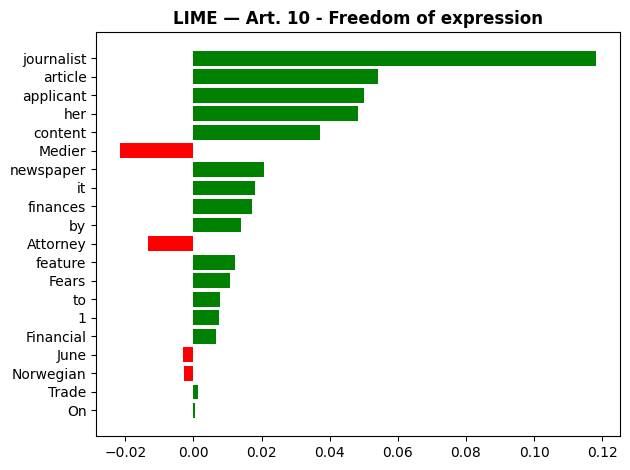

  Top LIME features:
    ↑ 'journalist': 0.1182
    ↑ 'article': 0.0541
    ↑ 'applicant': 0.0500
    ↑ 'her': 0.0482
    ↑ 'content': 0.0371
    ↓ 'Medier': -0.0216
    ↑ 'newspaper': 0.0206
    ↑ 'it': 0.0180
    ↑ 'finances': 0.0172
    ↑ 'by': 0.0140
✅ LIME done


In [19]:
print("\n🍋 LIME Explainability")

def lime_predict_fn(texts):
    """LIME needs a function: texts → probabilities."""
    all_probs = []
    for t in texts:
        p, _, _ = predict_text(t, xai_model, xai_tokenizer, device)
        all_probs.append(p)
    return np.array(all_probs)

explainer = lime.lime_text.LimeTextExplainer(
    class_names=config.ARTICLE_LABELS, split_expression=r'\W+', bow=True)

short_text = " ".join(sample_text.split()[:300])
probs, preds, _ = predict_text(short_text, xai_model, xai_tokenizer, device)
target_label = np.argmax(probs)

lime_exp = explainer.explain_instance(
    short_text, lime_predict_fn, num_features=20, num_samples=200, labels=[target_label])

fig = lime_exp.as_pyplot_figure(label=target_label)
plt.title(f"LIME — {config.ARTICLE_LABELS[target_label]}", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/xai/lime_explanation.png", dpi=150, bbox_inches="tight"); plt.show()

print("  Top LIME features:")
for word, weight in lime_exp.as_list(label=target_label)[:10]:
    d = "↑" if weight > 0 else "↓"
    print(f"    {d} '{word}': {weight:.4f}")
print("✅ LIME done")

### 4.4 Captum — Integrated Gradients


🧬 Captum — Integrated Gradients


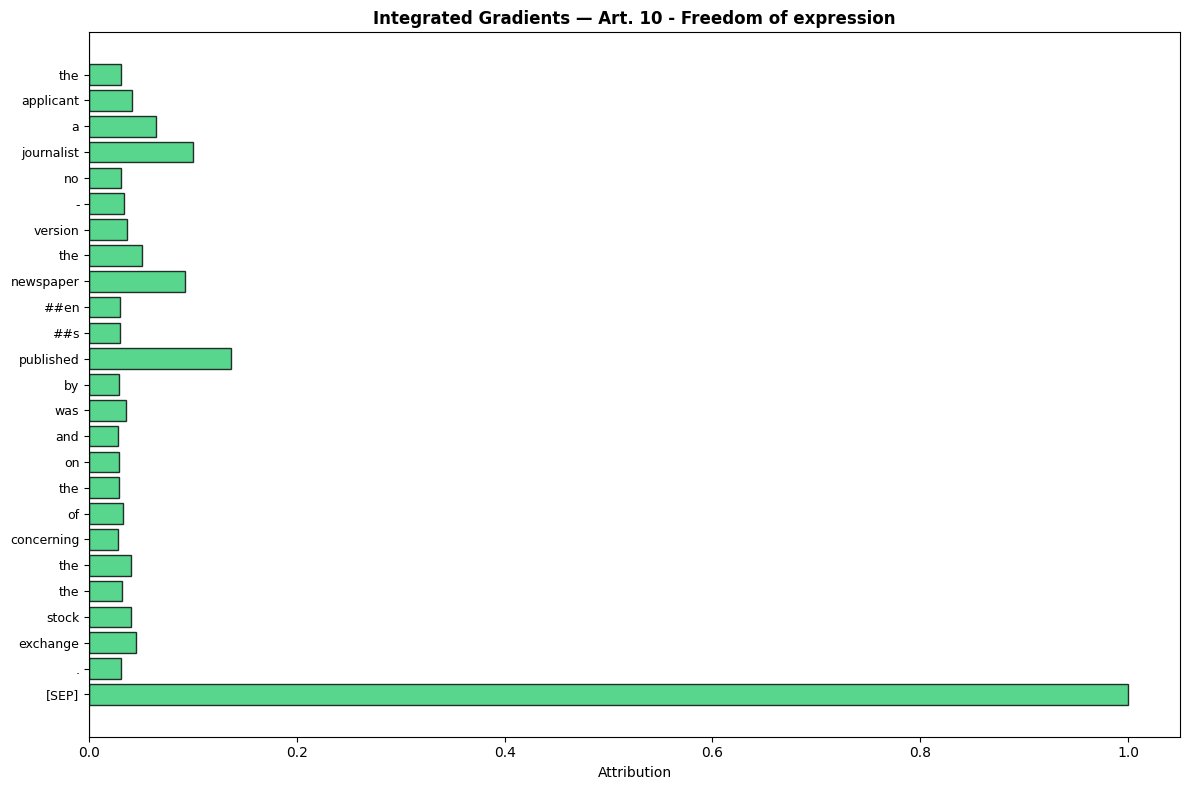

✅ Captum Integrated Gradients done


In [20]:
print("\n🧬 Captum — Integrated Gradients")

def captum_explain(text, model, tokenizer, device, target_label=None):
    from captum.attr import LayerIntegratedGradients
    import gc

    # Clear GPU memory before running
    torch.cuda.empty_cache()
    gc.collect()

    inputs = tokenizer(text, return_tensors="pt", max_length=512, truncation=True, padding="max_length")
    input_ids = inputs["input_ids"].to(device)
    attn_mask = inputs["attention_mask"].to(device)
    probs, preds, _ = predict_text(text, model, tokenizer, device)
    if target_label is None:
        target_label = int(np.argmax(probs))

    def fwd(ids, mask):
        return model(ids, mask)["logits"]

    ref_ids = torch.zeros_like(input_ids)
    ref_ids[:] = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

    lig = LayerIntegratedGradients(fwd, model.encoder.embeddings.word_embeddings)

    attrs, _ = lig.attribute(input_ids, ref_ids, additional_forward_args=(attn_mask,),
                             target=target_label, return_convergence_delta=True,
                             n_steps=20, internal_batch_size=5)
    attrs = attrs.sum(dim=-1).squeeze(0).cpu().detach().numpy()
    actual_len = int(attn_mask.sum().item())
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().numpy())[:actual_len]
    attrs = attrs[:actual_len]
    attrs = attrs / (np.max(np.abs(attrs)) + 1e-10)
    return tokens, attrs, target_label, probs

try:
    sample_short = " ".join(sample_text.split()[:80])
    cpt_tokens, cpt_attrs, cpt_target, cpt_probs = captum_explain(
        sample_short, xai_model, xai_tokenizer, device)

    top_k = min(25, len(cpt_tokens))
    abs_a = np.abs(cpt_attrs)
    top_idx = sorted(np.argsort(abs_a)[-top_k:])
    fig, ax = plt.subplots(figsize=(12, 8))
    tt = [cpt_tokens[j] for j in top_idx]
    ta = [cpt_attrs[j] for j in top_idx]
    colors = ["#2ecc71" if a > 0 else "#e74c3c" for a in ta]
    ax.barh(range(len(tt)), ta, color=colors, edgecolor="black", alpha=0.8)
    ax.set_yticks(range(len(tt))); ax.set_yticklabels(tt, fontsize=9)
    ax.set_title(f"Integrated Gradients — {config.ARTICLE_LABELS[cpt_target]}", fontweight="bold")
    ax.set_xlabel("Attribution"); ax.axvline(0, color="black", lw=0.8); ax.invert_yaxis()
    plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/xai/captum_ig.png", dpi=150); plt.show()
    print("✅ Captum Integrated Gradients done")
except Exception as e:
    print(f"⚠️ Captum error: {e}")


### 4.5 Attention Visualization


👁️ Attention Visualization


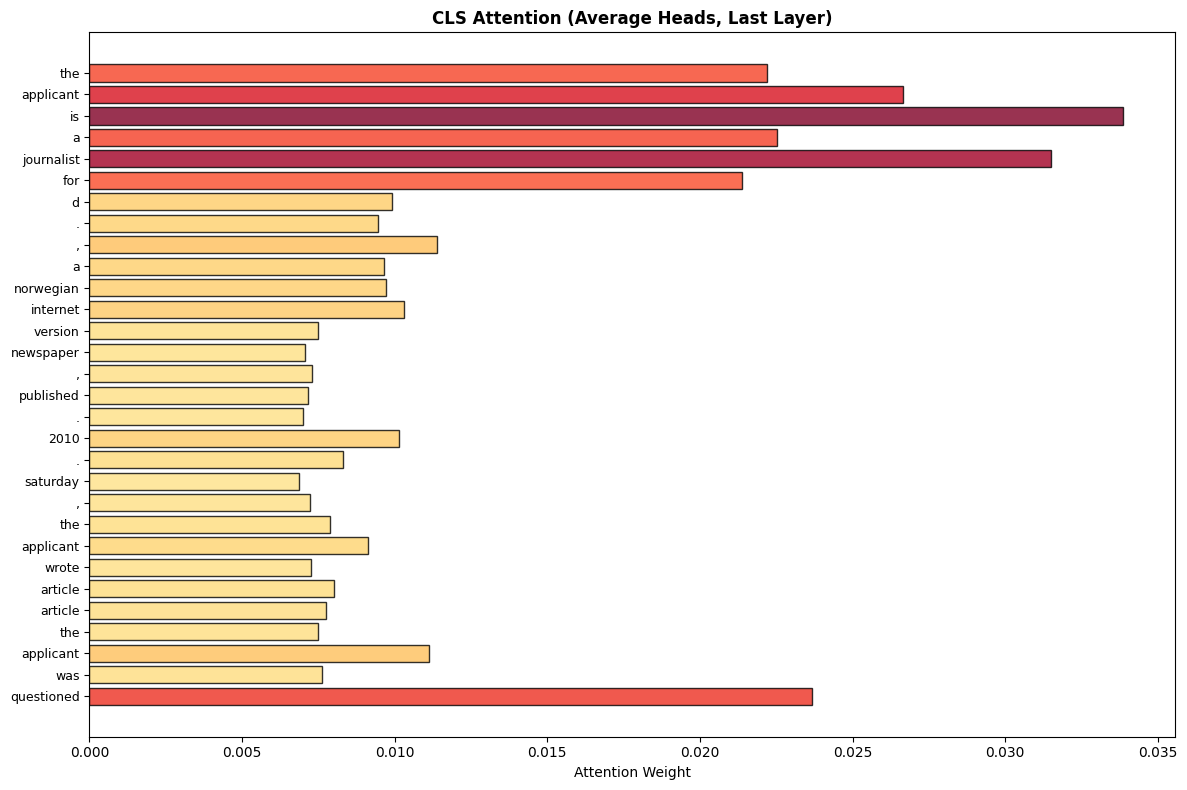

✅ Attention visualization done


In [21]:
print("\n👁️ Attention Visualization")

inputs = xai_tokenizer(sample_text, return_tensors="pt", max_length=512, truncation=True, padding="max_length")
input_ids = inputs["input_ids"].to(device)
attn_mask = inputs["attention_mask"].to(device)

# Switch to eager attention (SDPA doesn't support outputting attention weights)
xai_model.encoder.config._attn_implementation = "eager"
xai_model.encoder.config.output_attentions = True

with torch.no_grad():
    encoder_outputs = xai_model.encoder(input_ids=input_ids, attention_mask=attn_mask)

# Reset back
xai_model.encoder.config.output_attentions = False
xai_model.encoder.config._attn_implementation = "sdpa"

attn = encoder_outputs.attentions[-1][0]  # last layer, (heads, seq, seq)

actual_len = int(attn_mask.sum().item())
tokens = xai_tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().numpy())[:actual_len]
avg_cls_attn = attn[:, 0, :actual_len].mean(dim=0).cpu().numpy()

# Filter special tokens
filtered = [(t, a) for t, a in zip(tokens, avg_cls_attn) if t not in ["[CLS]","[SEP]","[PAD]","<s>","</s>","<pad>"]]
if filtered:
    ft, fa = zip(*filtered)
    top_k = min(30, len(ft))
    top_idx = np.argsort(fa)[-top_k:]
    fig, ax = plt.subplots(figsize=(12, 8))
    tt = [ft[j] for j in sorted(top_idx)]
    ta = [fa[j] for j in sorted(top_idx)]
    colors_a = plt.cm.YlOrRd(np.array(ta) / max(ta))
    ax.barh(range(len(tt)), ta, color=colors_a, edgecolor="black", alpha=0.8)
    ax.set_yticks(range(len(tt))); ax.set_yticklabels(tt, fontsize=9)
    ax.set_title("CLS Attention (Average Heads, Last Layer)", fontweight="bold")
    ax.set_xlabel("Attention Weight"); ax.invert_yaxis()
    plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/xai/attention_cls.png", dpi=150); plt.show()

    # Text heatmap
    max_a = max(fa)
    html = '<div style="font-family:monospace;line-height:2.2;padding:10px;">'
    html += '<h3>Attention Heatmap</h3>'
    for t, a in list(zip(ft, fa))[:100]:
        intensity = min(a / max_a * 2, 1.0)
        html += f'<span style="background:rgba(102,126,234,{intensity:.2f});padding:2px 4px;margin:1px;border-radius:3px;">{t}</span> '
    html += '</div>'
    display(HTML(html))
    with open(f"{config.OUTPUT_DIR}/xai/attention_heatmap.html", "w") as f:
        f.write(html)
print("✅ Attention visualization done")

### 4.6 Occlusion-based Sentence Importance


🔲 Occlusion-based Sentence Importance
  Target: Art. 10 - Freedom of expression (conf: 0.6145)
  Top 5 important sentences:
    1. [+0.2898] The applicant is a journalist for DN.no, a Norwegian Internet-based version of the newspaper Dagens ...
    2. [+0.1094] The Oslo stock exchange (Oslo børs) suspected market manipulation and, having looked into the matter...
    3. [+0.0394] Other media also reported on the first article, including an online newspaper (Hegnar online) which ...
    4. [+0.0196] The following day, on Saturday 25 August 2007, the applicant wrote an article entitled “Fears of DNO...
    5. [+0.0000] Information identifying a source In order to protect the identity of a source adequately, it is nece...


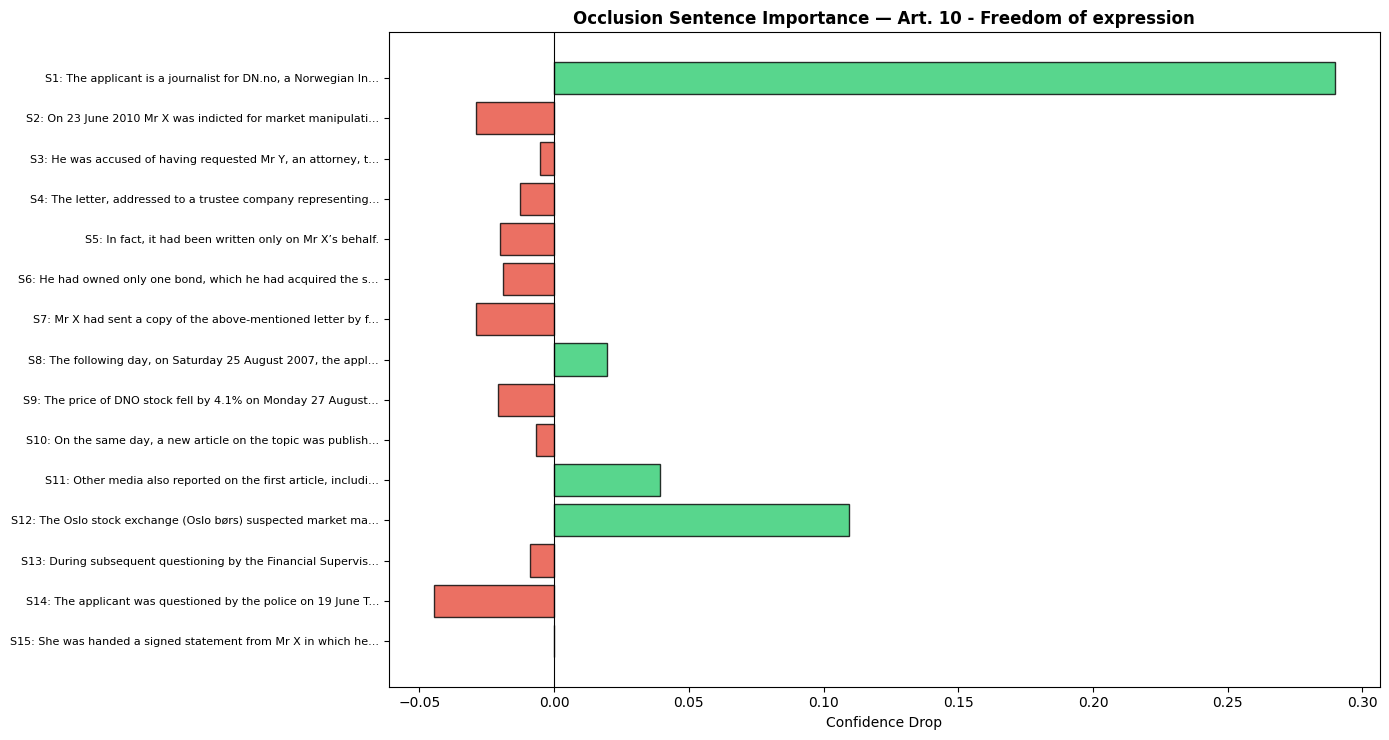

In [22]:
print("\n🔲 Occlusion-based Sentence Importance")

sentences = re.split(r'(?<=[.!?])\s+', sample_text)
sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
base_probs, _, _ = predict_text(sample_text, xai_model, xai_tokenizer, device)
occ_target = np.argmax(base_probs)
base_conf = base_probs[occ_target]

occ_scores = []
for i, s in enumerate(sentences):
    occ_text = " ".join([ss for j, ss in enumerate(sentences) if j != i])
    occ_probs, _, _ = predict_text(occ_text, xai_model, xai_tokenizer, device)
    occ_scores.append(base_conf - occ_probs[occ_target])

sorted_idx = np.argsort(occ_scores)[::-1]
print(f"  Target: {config.ARTICLE_LABELS[occ_target]} (conf: {base_conf:.4f})")
print(f"  Top 5 important sentences:")
for rank, idx in enumerate(sorted_idx[:5]):
    print(f"    {rank+1}. [{occ_scores[idx]:+.4f}] {sentences[idx][:100]}...")

fig, ax = plt.subplots(figsize=(14, max(6, len(sentences[:15]) * 0.5)))
display_s = [f"S{i+1}: {s[:55]}..." if len(s)>55 else f"S{i+1}: {s}" for i, s in enumerate(sentences[:15])]
display_sc = occ_scores[:15]
colors_o = ["#2ecc71" if s > 0 else "#e74c3c" for s in display_sc]
ax.barh(range(len(display_s)), display_sc, color=colors_o, edgecolor="black", alpha=0.8)
ax.set_yticks(range(len(display_s))); ax.set_yticklabels(display_s, fontsize=8)
ax.set_title(f"Occlusion Sentence Importance — {config.ARTICLE_LABELS[occ_target]}", fontweight="bold")
ax.set_xlabel("Confidence Drop"); ax.axvline(0, color="black", lw=0.8); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/xai/occlusion_sentences.png", dpi=150); plt.show()


### 4.7 XAI Methods Summary

In [23]:
xai_summary = pd.DataFrame({
    "Method": ["SHAP-style", "LIME", "Integrated Gradients", "Attention", "Occlusion"],
    "Type": ["Model-agnostic", "Model-agnostic", "Gradient-based", "Internal", "Perturbation"],
    "Granularity": ["Word", "Word", "Token", "Token", "Sentence"],
})
print("\n XAI Methods Summary:")
print(xai_summary.to_string(index=False))
print("\n✅ Part 4 complete — XAI done")


 XAI Methods Summary:
              Method           Type Granularity
          SHAP-style Model-agnostic        Word
                LIME Model-agnostic        Word
Integrated Gradients Gradient-based       Token
           Attention       Internal       Token
           Occlusion   Perturbation    Sentence

✅ Part 4 complete — XAI done


### Save Results to Google Drive

In [25]:
# === SAVE ALL RESULTS TO GOOGLE DRIVE ===
import shutil

DRIVE_RESULTS_DIR = "/content/drive/MyDrive/Jurisight_Results"
os.makedirs(DRIVE_RESULTS_DIR, exist_ok=True)

# 1. Save test_results
test_results_save = {}
for mk in config.MODEL_NAMES:
    test_results_save[mk] = {
        "labels": test_results[mk]["labels"].tolist(),
        "preds": test_results[mk]["preds"].tolist(),
        "probs": test_results[mk]["probs"].tolist()
    }
with open(f"{DRIVE_RESULTS_DIR}/test_results.json", "w") as f:
    json.dump(test_results_save, f)
print("✅ Test results saved")

# 2. Save training histories (extract from checkpoints if not in memory)
try:
    th = training_histories
except NameError:
    th = {}
    for mk in config.MODEL_NAMES:
        cp = torch.load(f"{config.MODEL_DIR}/{mk}/best_model.pt", map_location="cpu", weights_only=False)
        th[mk] = cp.get("history", {})
with open(f"{DRIVE_RESULTS_DIR}/training_histories.json", "w") as f:
    json.dump(th, f)
print("✅ Training histories saved")

# 3. Save comparison CSV
comparison_df.to_csv(f"{DRIVE_RESULTS_DIR}/model_comparison.csv", index=False)
print("✅ Comparison table saved")

# 4. Save fairness results
with open(f"{DRIVE_RESULTS_DIR}/fairness_results.json", "w") as f:
    json.dump({mk: {k: {kk: float(vv) for kk,vv in v.items()} for k,v in cls.items()} for mk, cls in fairness_results.items()}, f, indent=2)
print("✅ Fairness results saved")

# 5. Copy ALL generated plots to Drive
plots_dir = f"{DRIVE_RESULTS_DIR}/plots"
os.makedirs(plots_dir, exist_ok=True)
for f_name in os.listdir(config.OUTPUT_DIR):
    src = f"{config.OUTPUT_DIR}/{f_name}"
    if os.path.isfile(src):
        shutil.copy2(src, f"{plots_dir}/{f_name}")
xai_plots_dir = f"{plots_dir}/xai"
os.makedirs(xai_plots_dir, exist_ok=True)
xai_src = f"{config.OUTPUT_DIR}/xai"
if os.path.exists(xai_src):
    for f_name in os.listdir(xai_src):
        src = f"{xai_src}/{f_name}"
        if os.path.isfile(src):
            shutil.copy2(src, f"{xai_plots_dir}/{f_name}")
print("✅ All plots saved")

# 6. Save best scores (extract from checkpoints if not in memory)
try:
    bs = best_scores
except NameError:
    bs = {}
    for mk in config.MODEL_NAMES:
        cp = torch.load(f"{config.MODEL_DIR}/{mk}/best_model.pt", map_location="cpu", weights_only=False)
        bs[mk] = cp.get("best_val_f1", 0)
with open(f"{DRIVE_RESULTS_DIR}/best_scores.json", "w") as f:
    json.dump(bs, f)
print("✅ Best scores saved")

print(f"\n🎉 EVERYTHING SAVED! Location: {DRIVE_RESULTS_DIR}")


✅ Test results saved
✅ Training histories saved
✅ Comparison table saved
✅ Fairness results saved
✅ All plots saved
✅ Best scores saved

🎉 EVERYTHING SAVED! Location: /content/drive/MyDrive/Jurisight_Results


### Loading Models,Results from Google Drive - For Less Time

In [ ]:
# ══════════════════════════════════════════════════════════════
# Load EVERYTHING from Google Drive (NO training, NO evaluation)
# ══════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')
import shutil
from IPython.display import Image, display, HTML

DRIVE_SAVE_DIR = "/content/drive/MyDrive/Jurisight_Models"
DRIVE_RESULTS_DIR = "/content/drive/MyDrive/Jurisight_Results"

# ── 1. Load trained models ──
print("📦 Loading trained models from Google Drive...")
trained_models = {}
tokenizers = {}
for model_key, model_name in config.MODEL_NAMES.items():
    src = f"{DRIVE_SAVE_DIR}/{model_key}"
    dst = f"{config.MODEL_DIR}/{model_key}"
    if os.path.exists(src):
        os.makedirs(dst, exist_ok=True)
        shutil.copytree(src, dst, dirs_exist_ok=True)
    checkpoint = torch.load(f"{dst}/best_model.pt", map_location=device, weights_only=False)
    model = ECHRClassifier(checkpoint["model_name"], checkpoint["num_labels"])
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device); model.eval()
    trained_models[model_key] = model
    tokenizers[model_key] = AutoTokenizer.from_pretrained(checkpoint["model_name"])
    print(f"  ✅ {model_key}: Val F1 = {checkpoint.get('best_val_f1', 'N/A'):.4f}")

# ── 2. Load test results (NO re-evaluation needed!) ──
print("\n📊 Loading saved test results...")
with open(f"{DRIVE_RESULTS_DIR}/test_results.json") as f:
    test_results_raw = json.load(f)
test_results = {mk: {k: np.array(v) for k,v in data.items()} for mk, data in test_results_raw.items()}
for mk in config.MODEL_NAMES:
    micro = f1_score(test_results[mk]["labels"], test_results[mk]["preds"], average="micro", zero_division=0)
    macro = f1_score(test_results[mk]["labels"], test_results[mk]["preds"], average="macro", zero_division=0)
    print(f"  {mk.upper()}: Micro-F1={micro:.4f}, Macro-F1={macro:.4f}")

# ── 3. Load training histories ──
with open(f"{DRIVE_RESULTS_DIR}/training_histories.json") as f:
    training_histories = json.load(f)

# ── 4. Load comparison table ──
print("\n📋 Model Comparison:")
comparison_df = pd.read_csv(f"{DRIVE_RESULTS_DIR}/model_comparison.csv")
print(comparison_df.to_string(index=False, float_format="%.4f"))
comparison_df.to_csv(f"{config.OUTPUT_DIR}/model_comparison.csv", index=False)

# ── 5. Load fairness results ──
with open(f"{DRIVE_RESULTS_DIR}/fairness_results.json") as f:
    fairness_results = json.load(f)

# ── 6. Load best scores ──
with open(f"{DRIVE_RESULTS_DIR}/best_scores.json") as f:
    best_scores = json.load(f)

# ── 7. Copy plots locally & display them ──
print("\n🖼️ Loading all visualizations...")
plots_src = f"{DRIVE_RESULTS_DIR}/plots"
if os.path.exists(plots_src):
    shutil.copytree(plots_src, config.OUTPUT_DIR, dirs_exist_ok=True)

# ── 8. Save test text for web app XAI ──
print("\n📥 Loading ECHR dataset for web app...")
dataset = load_dataset(config.DATASET_NAME, config.DATASET_CONFIG)
test_texts = [" ".join(item["text"]) for item in dataset["test"]]
test_labels_raw = [item["labels"] for item in dataset["test"]]
mlb = MultiLabelBinarizer(classes=list(range(config.NUM_LABELS)))
test_labels = mlb.fit_transform(test_labels_raw).tolist()
with open(f"{config.DATA_DIR}/test_processed.json", "w") as f:
    json.dump({"text": test_texts, "labels": test_labels}, f)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Loading trained models from Google Drive...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

ecthr_a/test-00000-of-00001.parquet:   0%|          | 0.00/5.68M [00:00<?, ?B/s]

ecthr_a/validation-00000-of-00001.parque(…):   0%|          | 0.00/5.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

📊 PART 2 & 3: Training & Evaluation Plots

📈 cm_bert.png


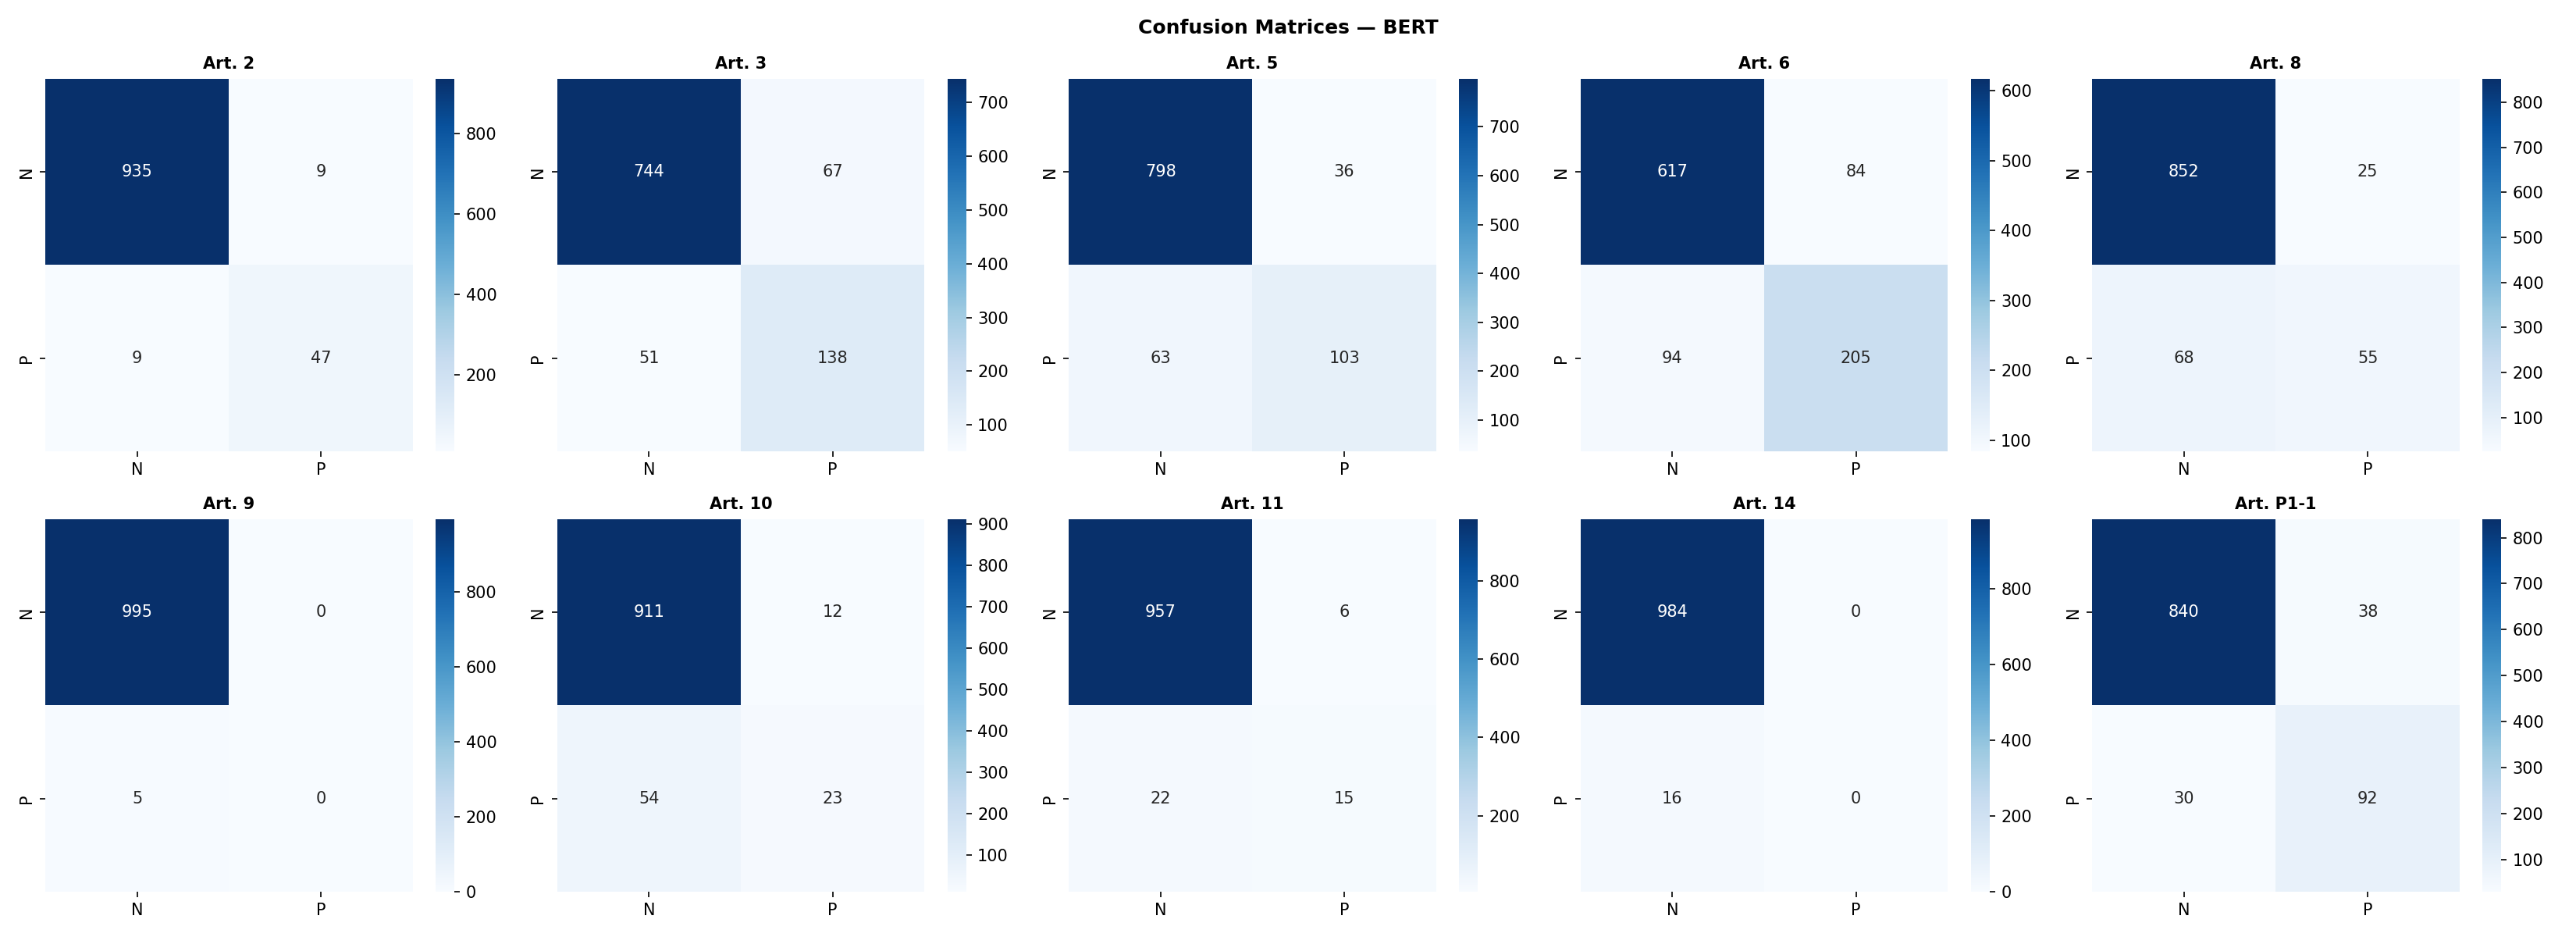


📈 cm_legal-bert.png


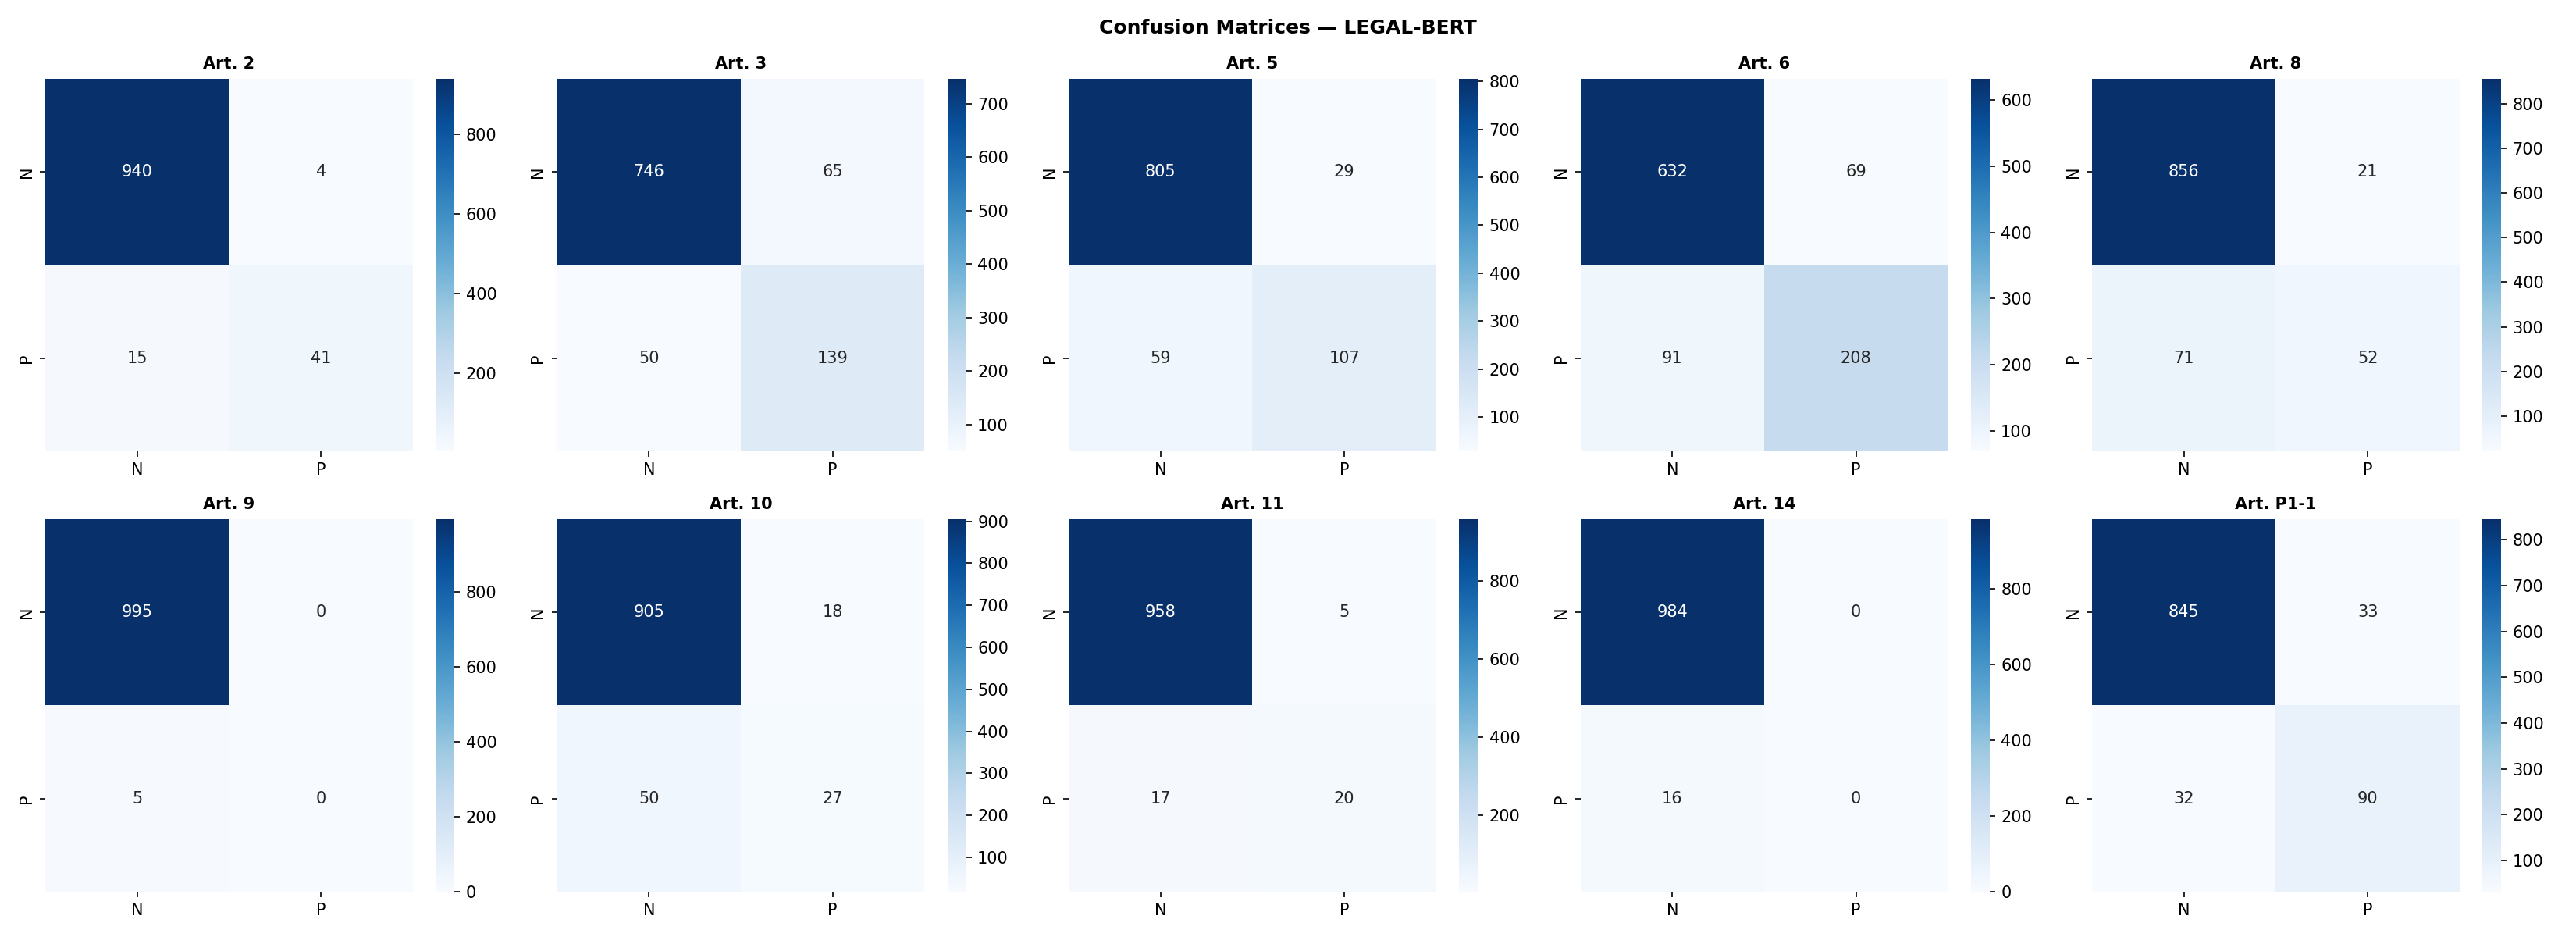


📈 cm_roberta.png


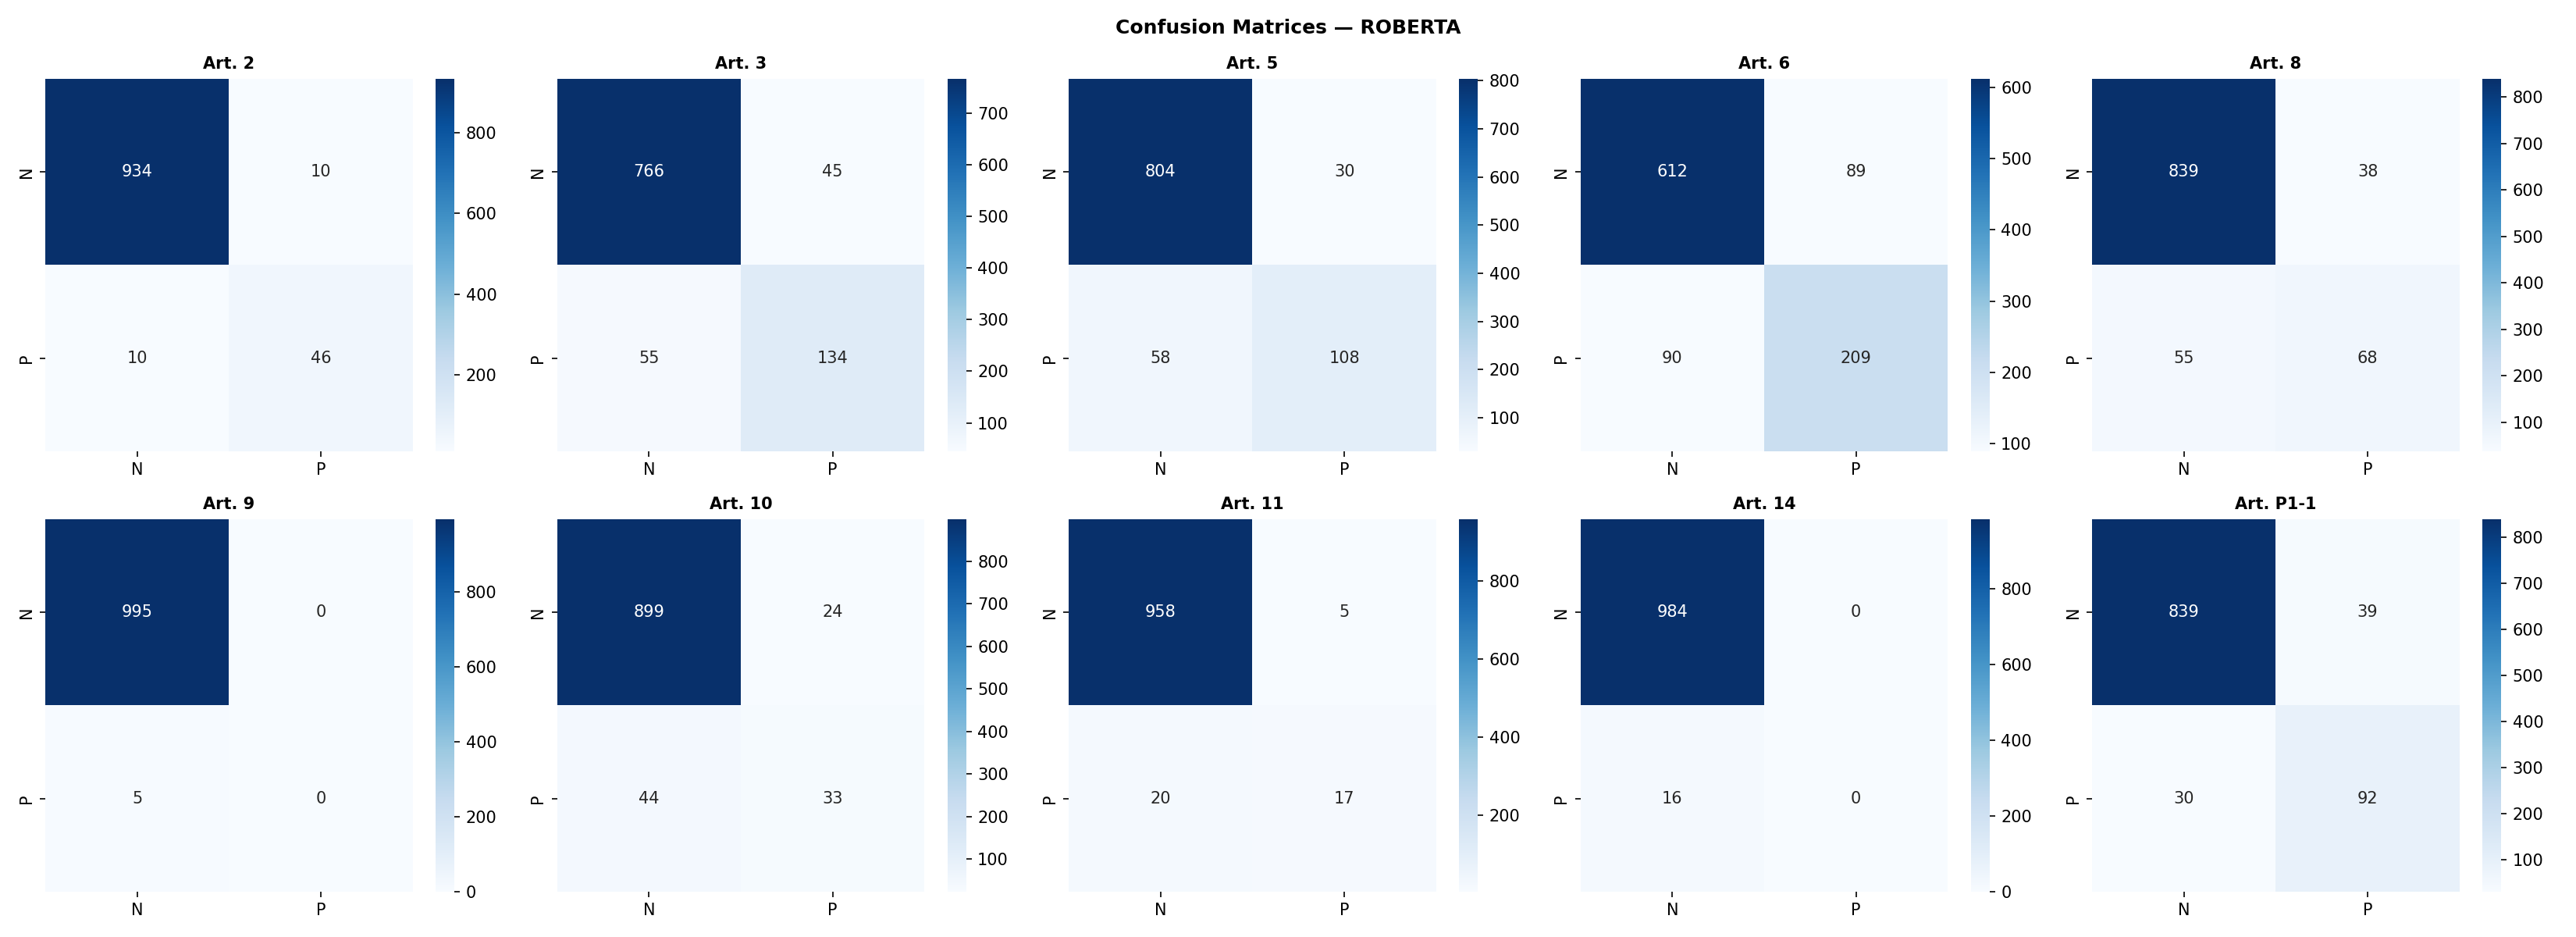


📈 dataset_exploration.png


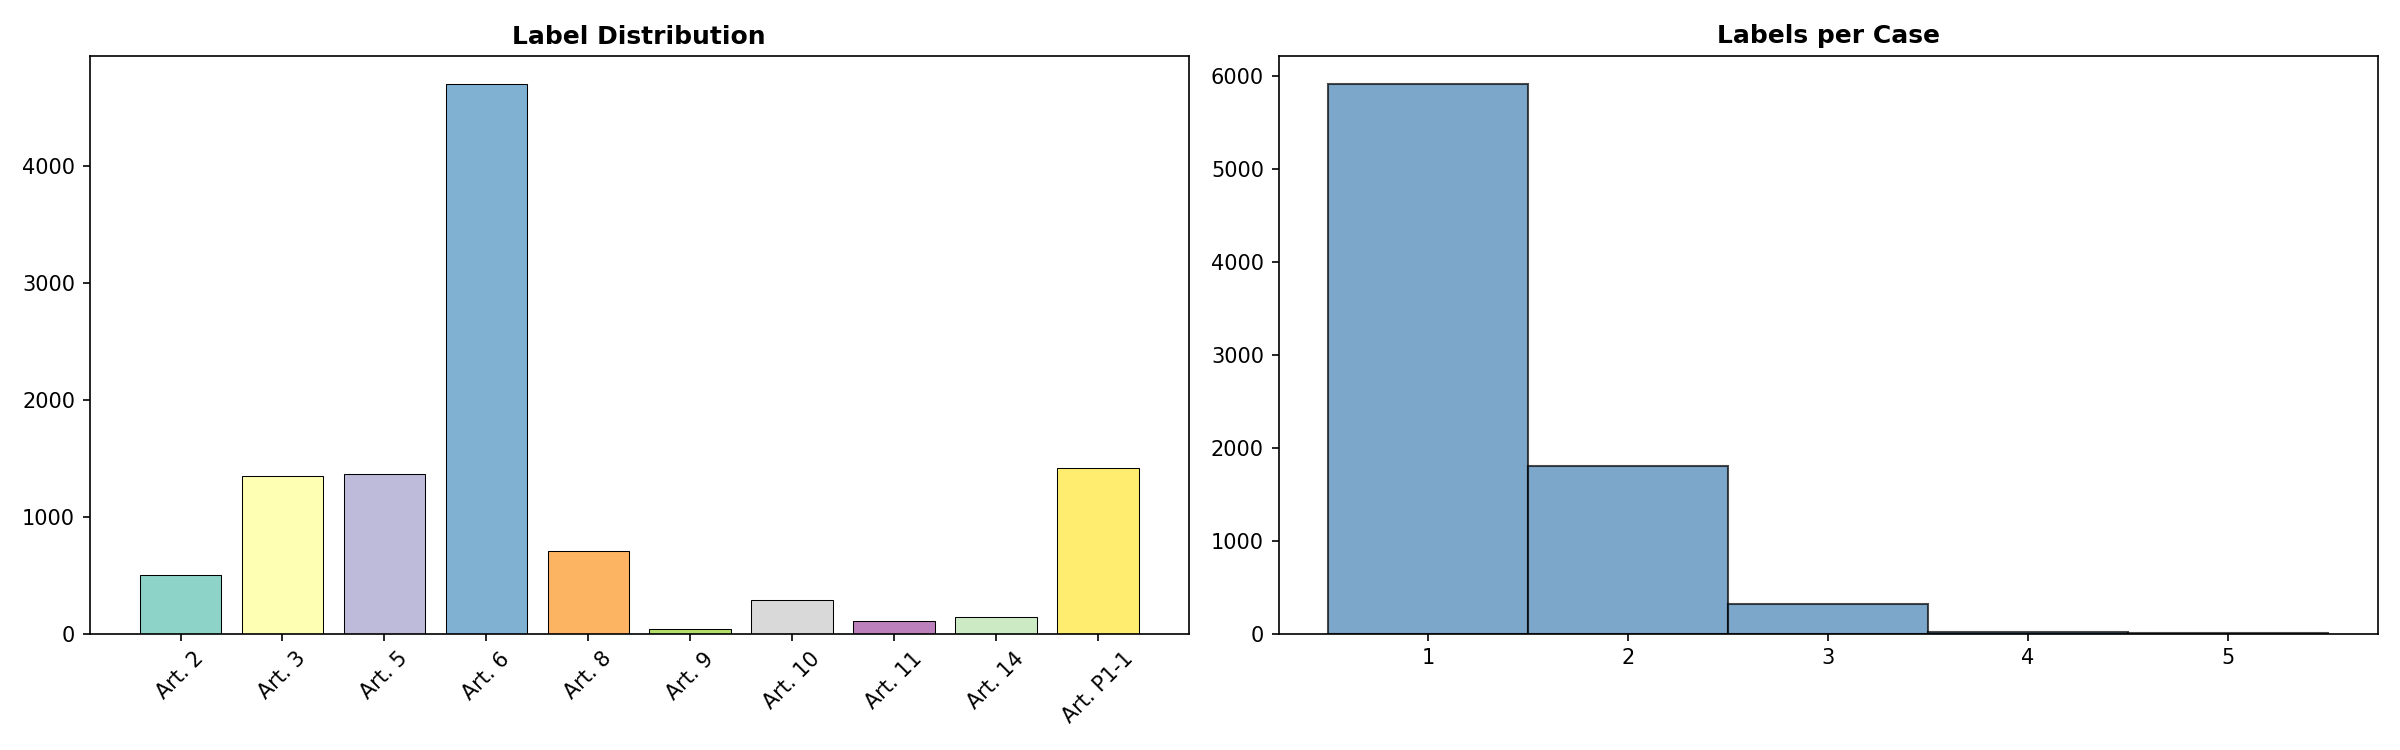


📈 fairness_heatmap.png


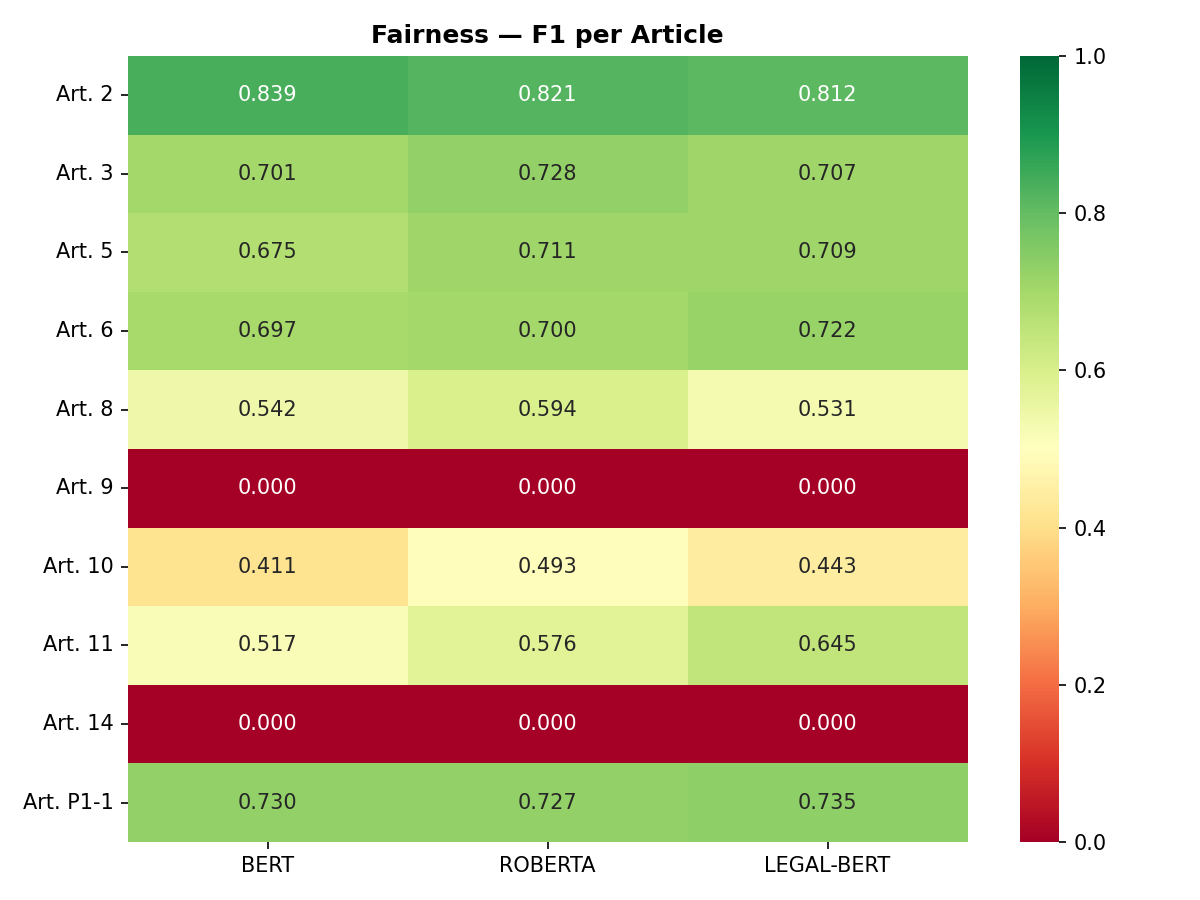


📈 roc_curves.png


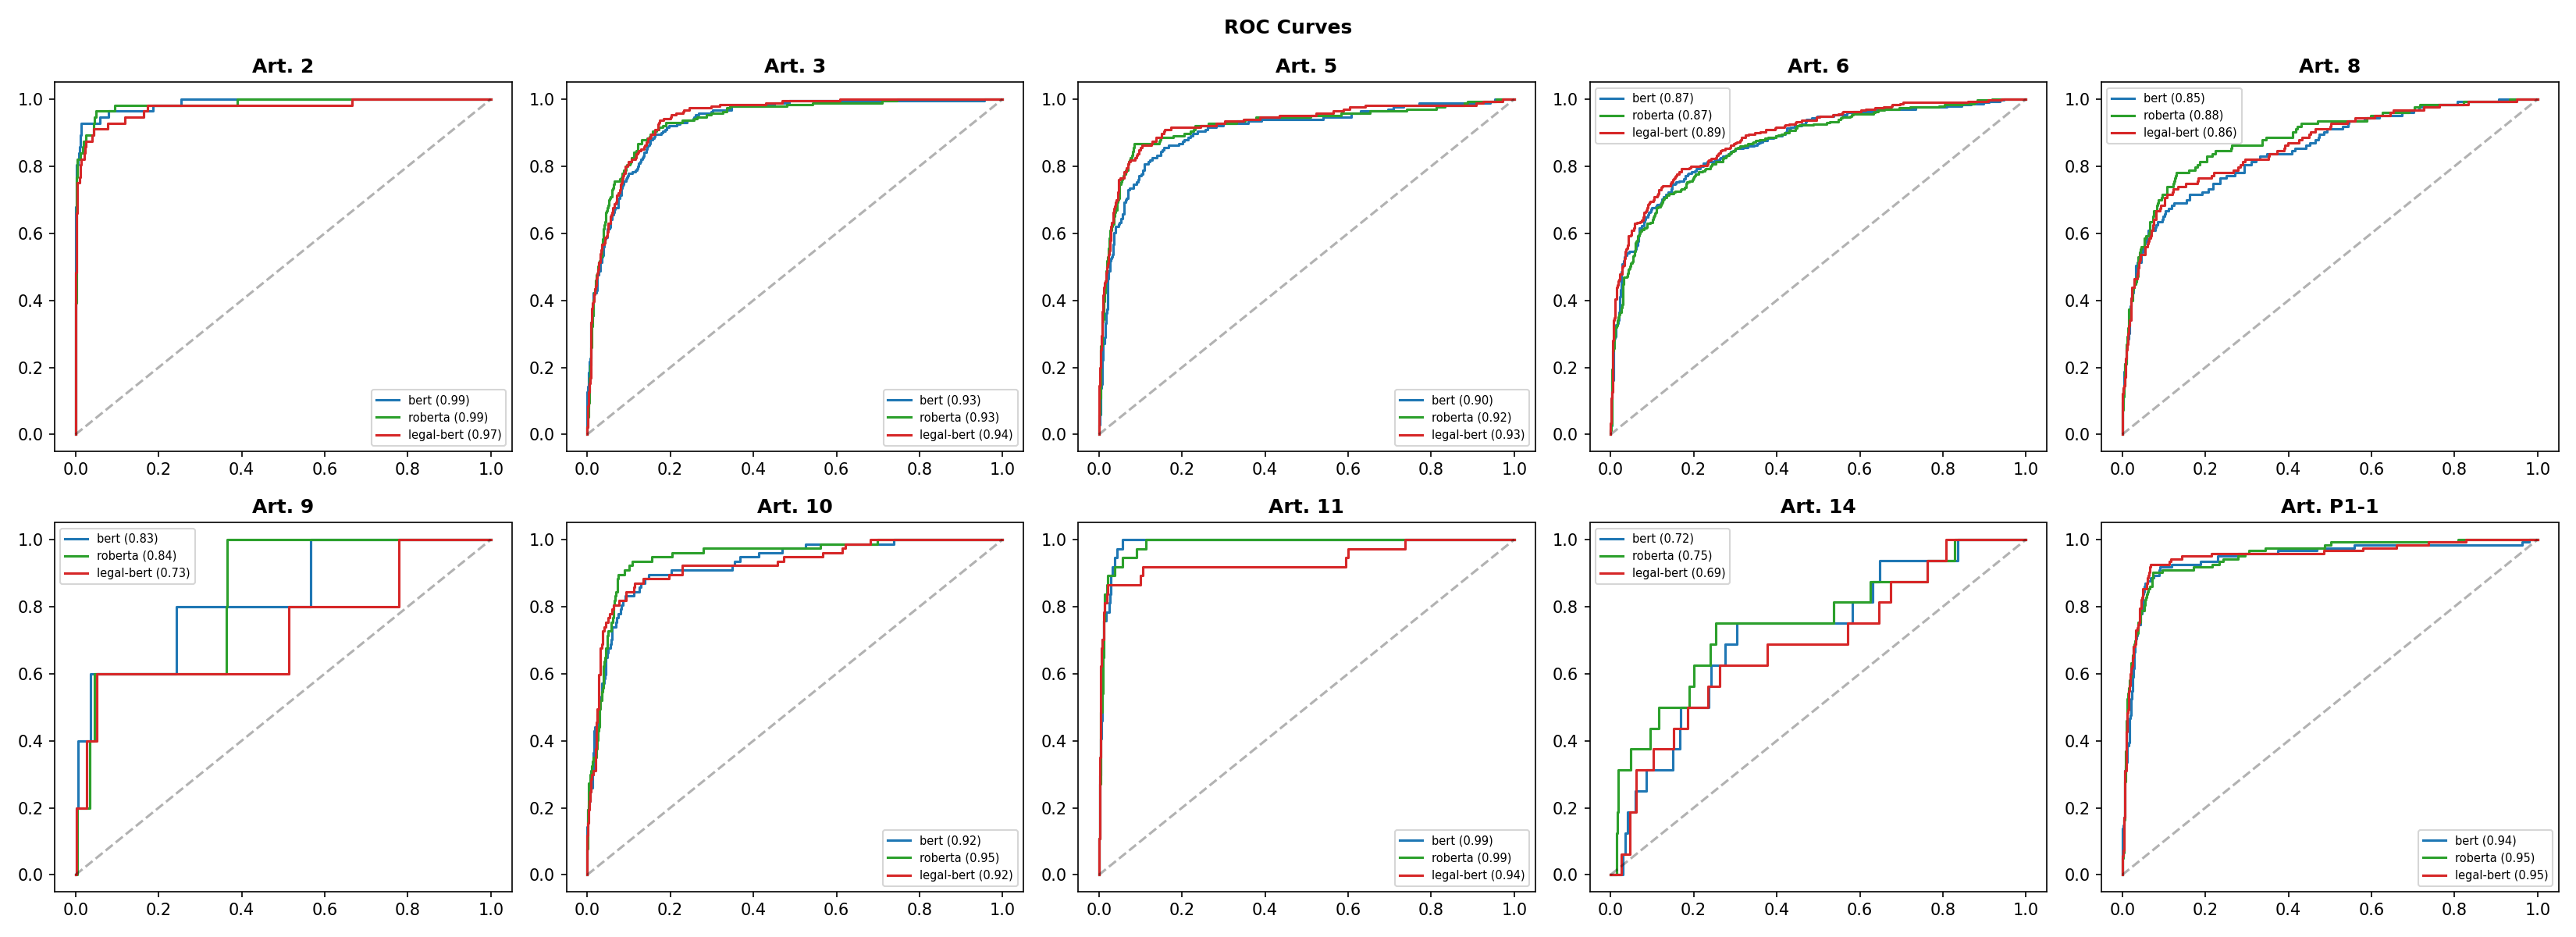


🔍 PART 4: XAI Visualizations

📈 attention_cls.png


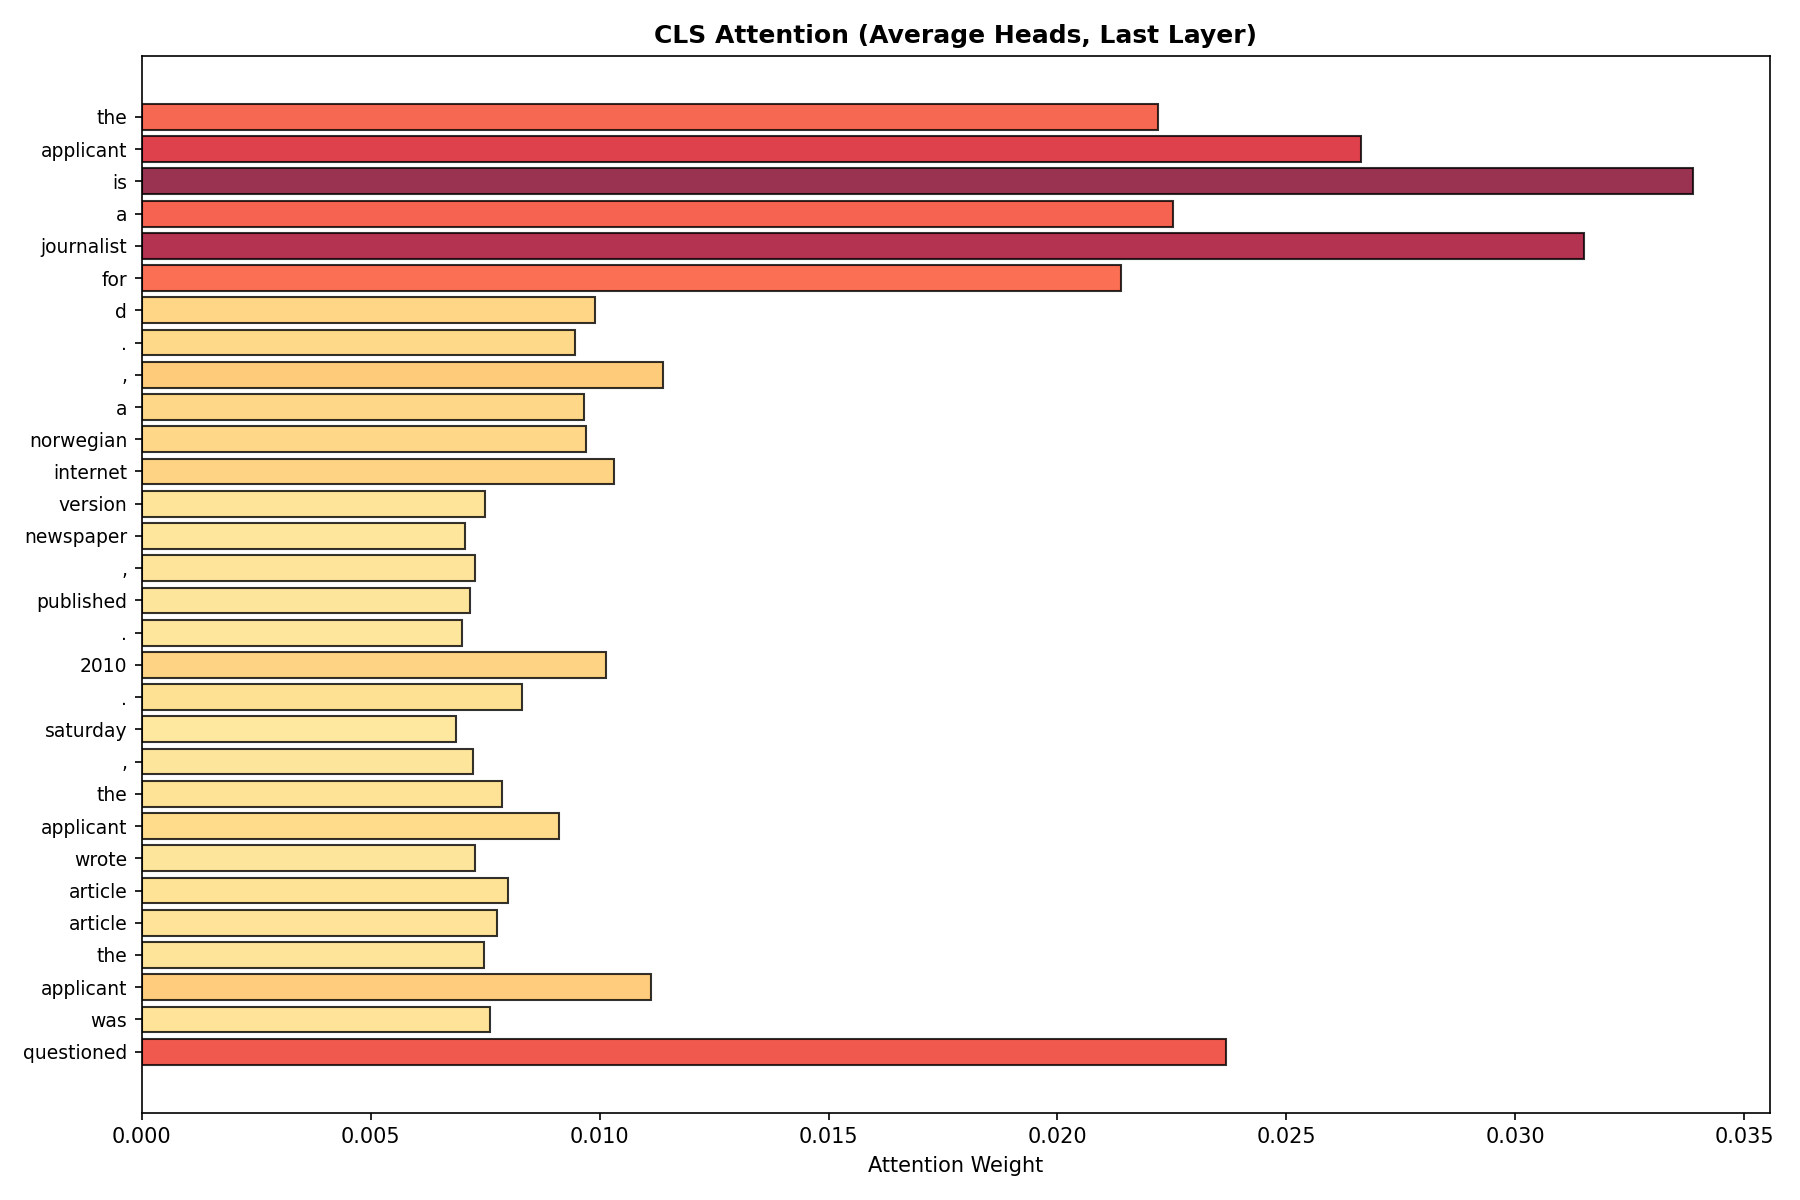


📈 captum_ig.png


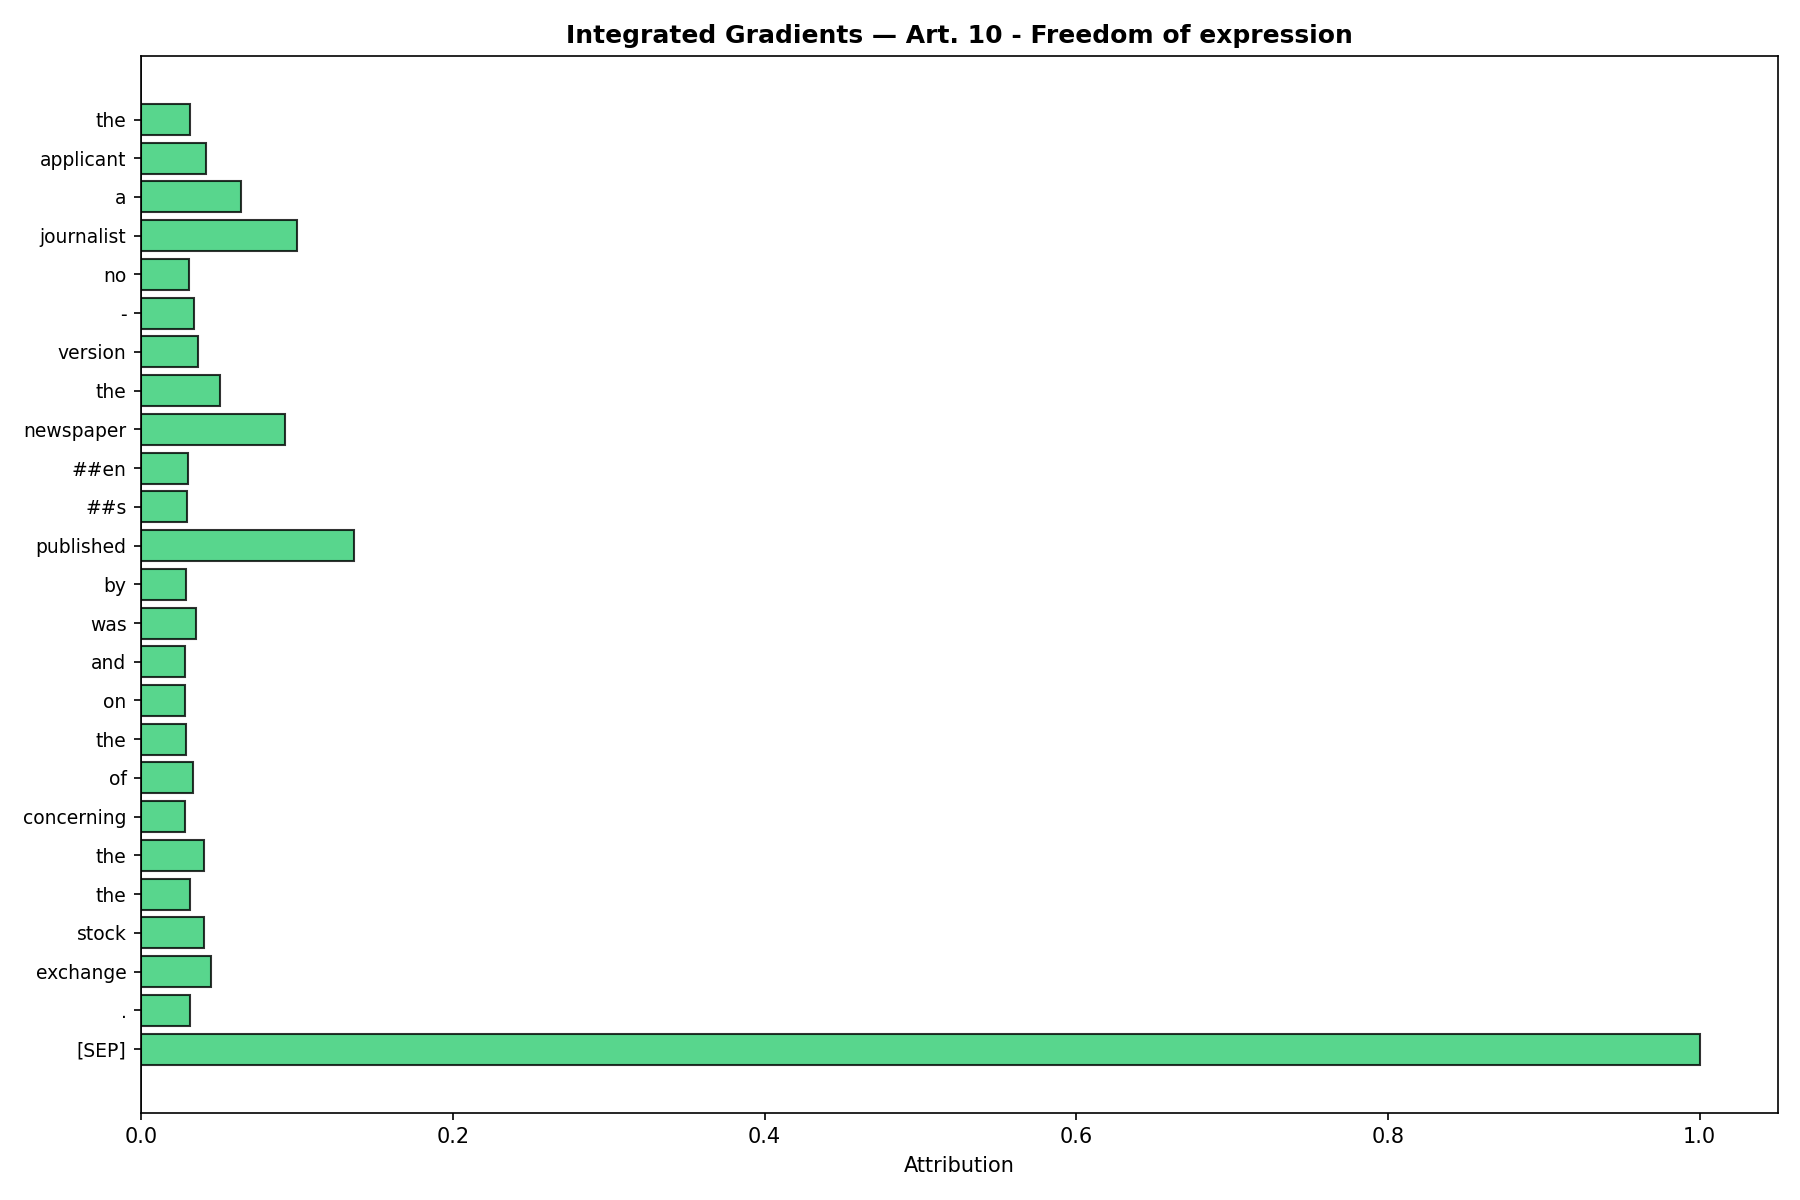


📈 lime_explanation.png


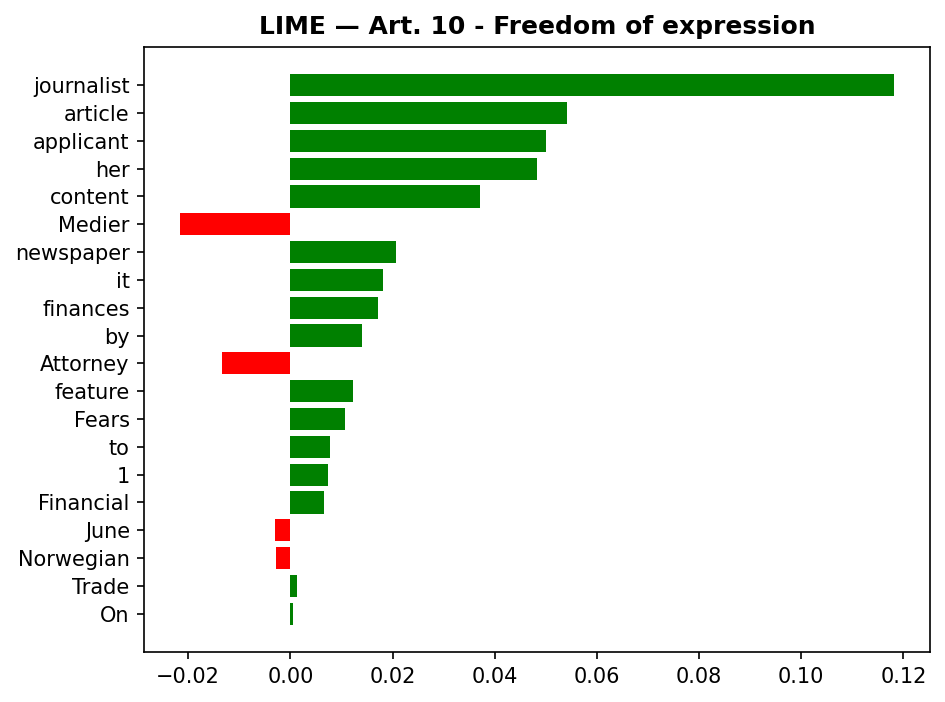


📈 occlusion_sentences.png


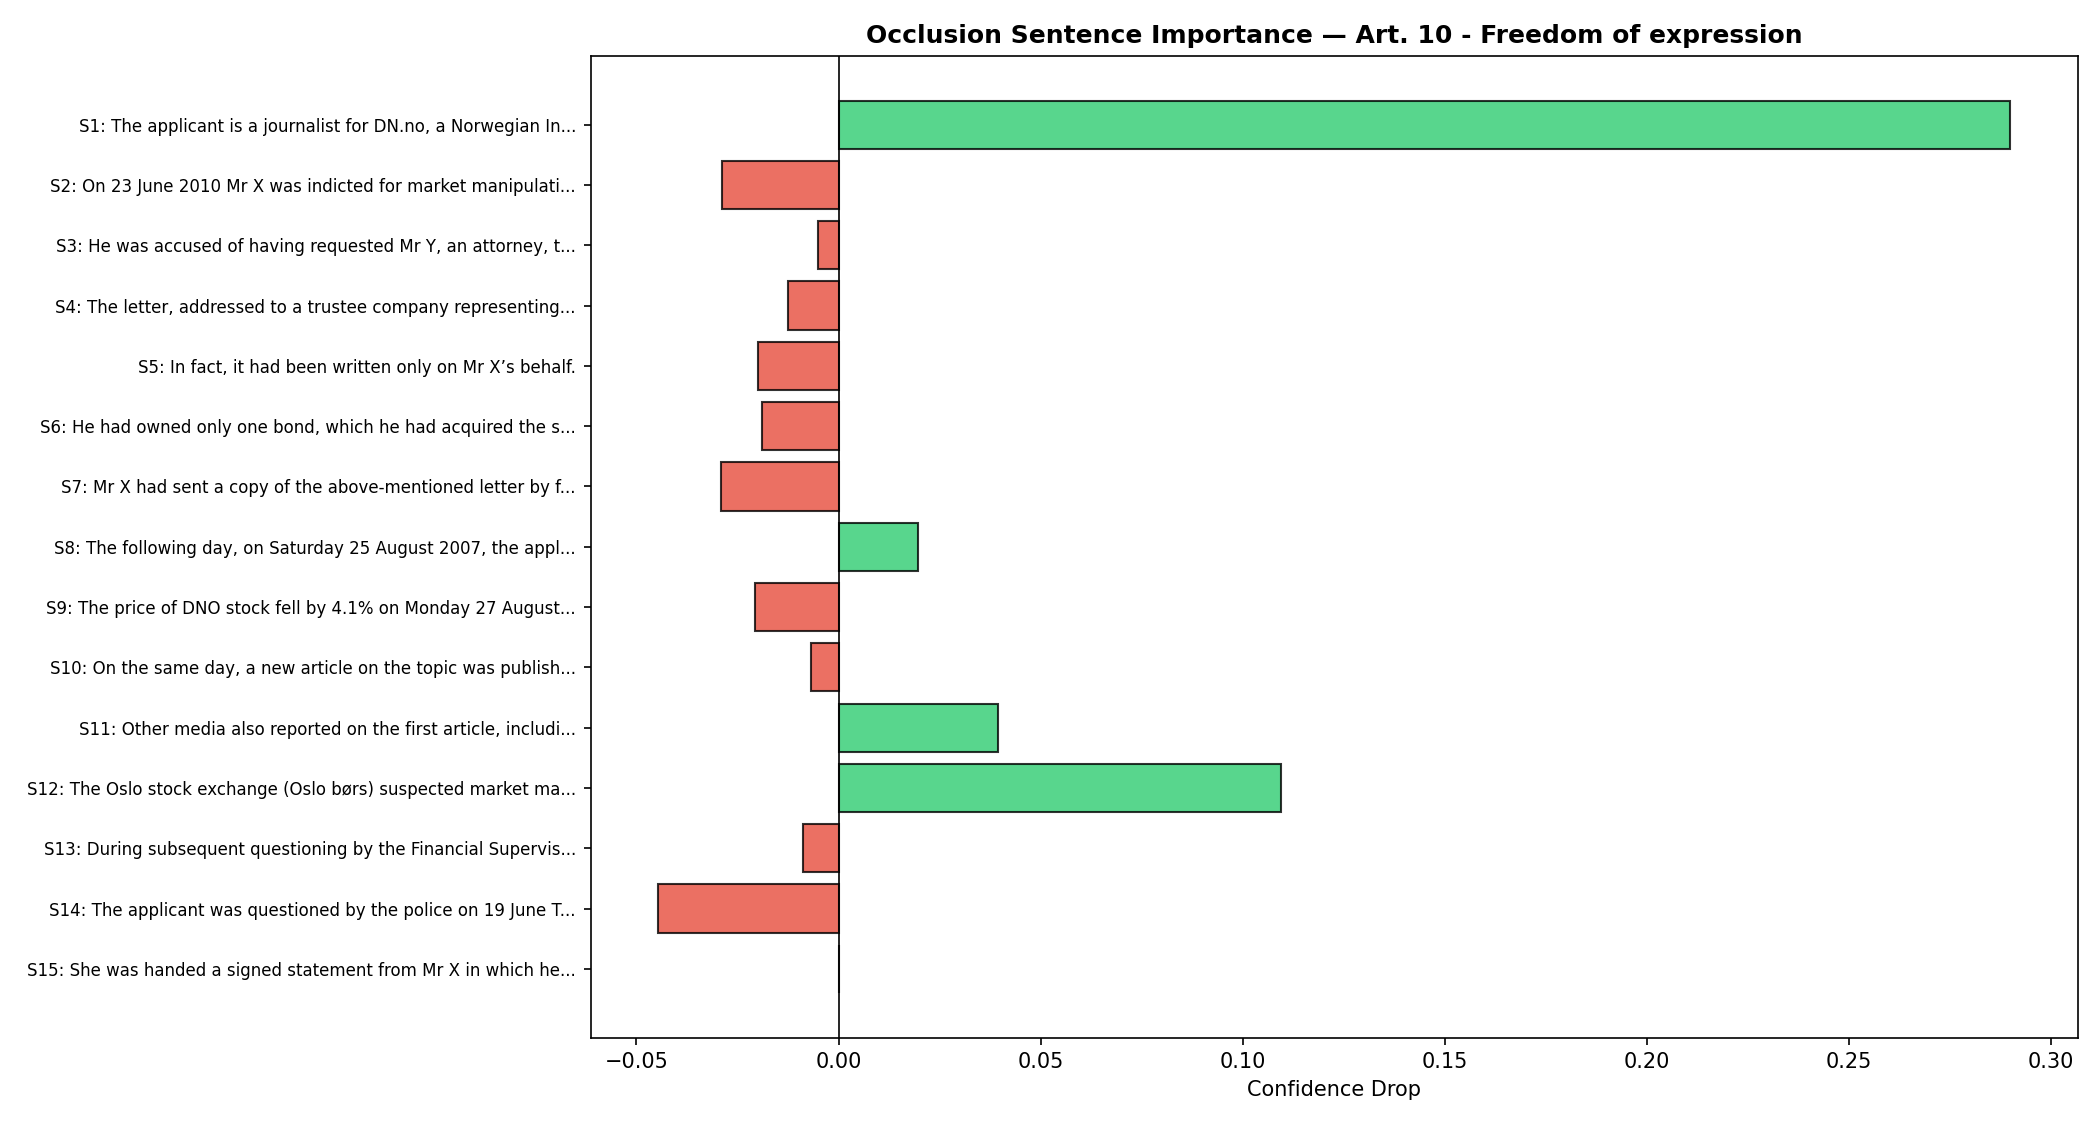


📈 shap_features.png


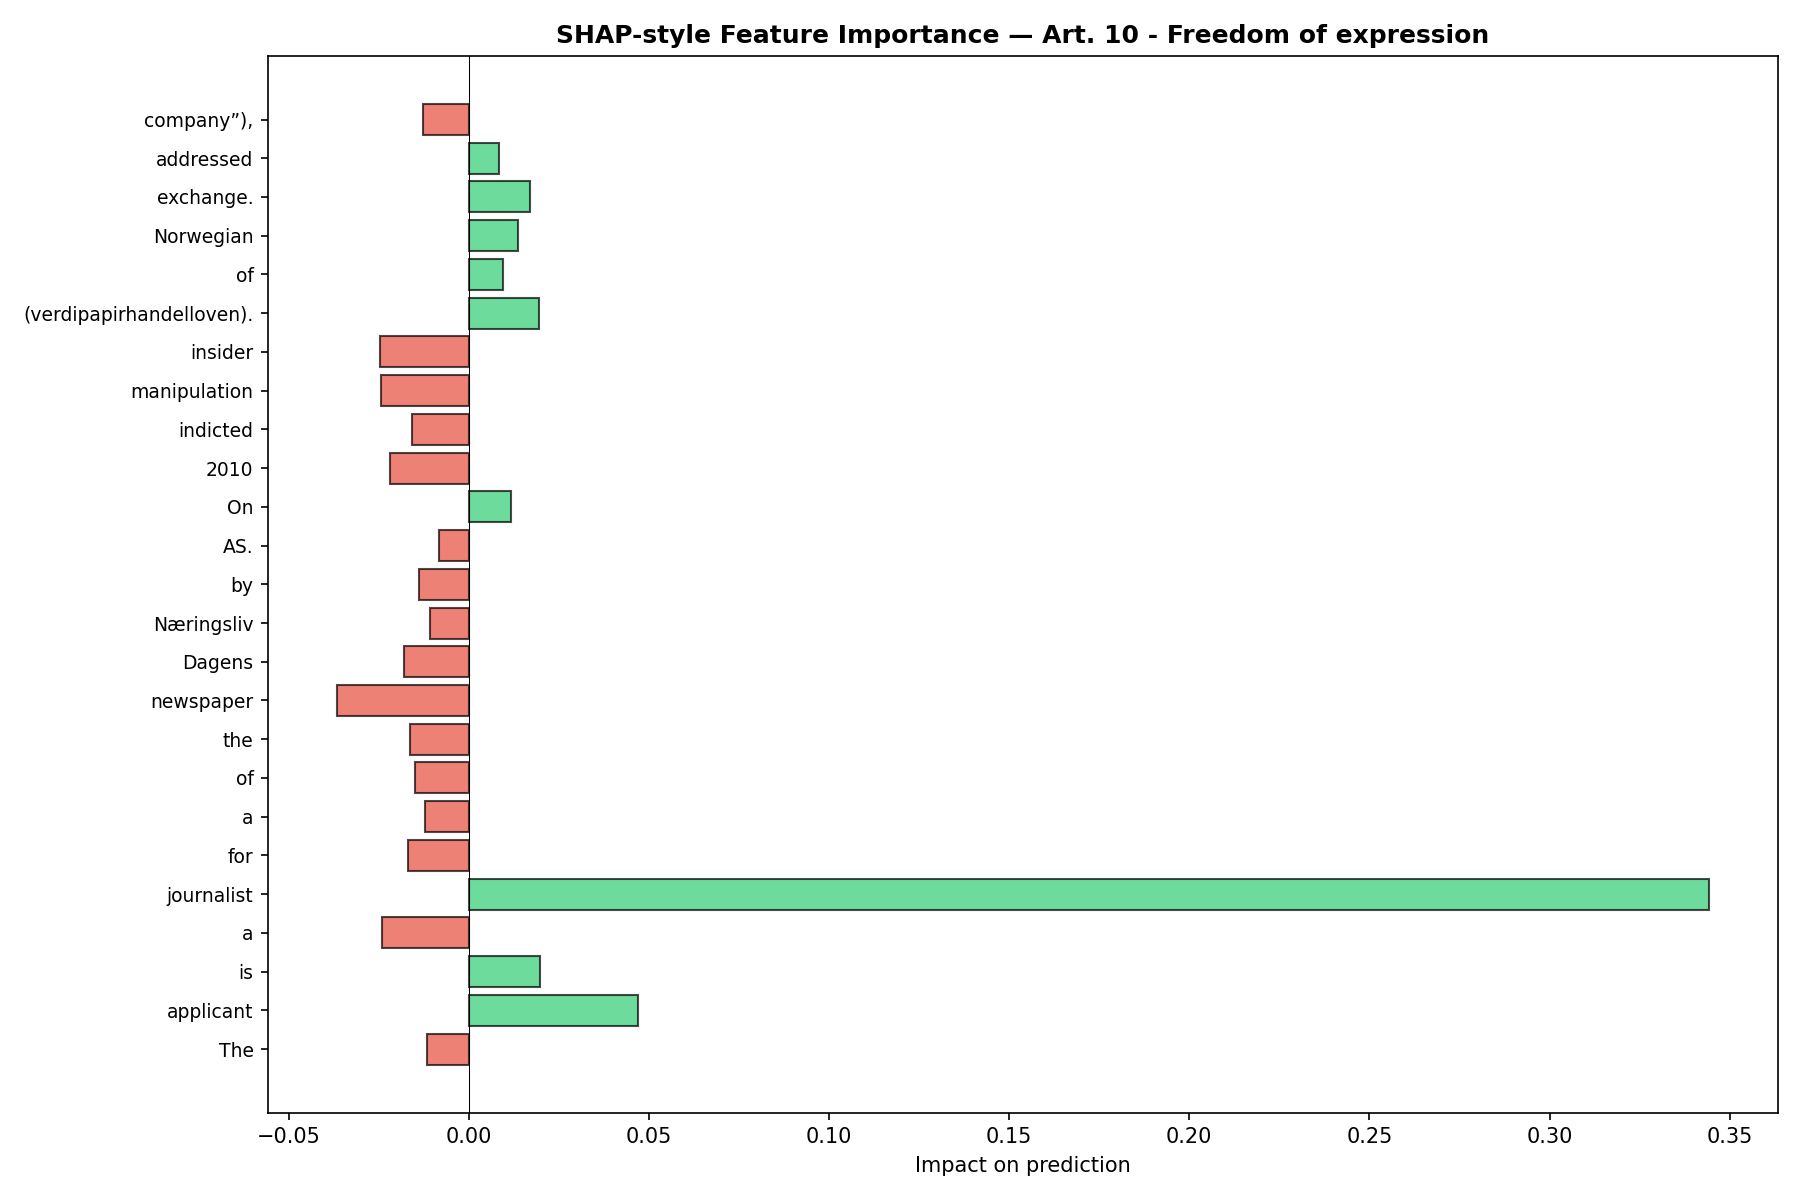


✅ All visualizations displayed! Now run Part 5 cells to launch the web app.


In [7]:
# === DISPLAY ALL SAVED VISUALIZATIONS ===
from IPython.display import Image, display
import glob

plot_files = sorted(glob.glob(f"{config.OUTPUT_DIR}/*.png"))
xai_files = sorted(glob.glob(f"{config.OUTPUT_DIR}/xai/*.png"))

print("=" * 60)
print("📊 PART 2 & 3: Training & Evaluation Plots")
print("=" * 60)
for p in plot_files:
    print(f"\n📈 {os.path.basename(p)}")
    display(Image(p))

print("\n" + "=" * 60)
print("🔍 PART 4: XAI Visualizations")
print("=" * 60)
for p in xai_files:
    print(f"\n📈 {os.path.basename(p)}")
    display(Image(p))

print("\n✅ All visualizations displayed! Now run Part 5 cells to launch the web app.")


---
##  Part 5: Web Application

A Flask API backend with a custom HTML/CSS/JS frontend for interactive predictions and explanations.

**Features:**
- **Home** — Project overview and feature cards
- **Predict** — Paste case facts → get verdict (VIOLATION / NO VIOLATION) with per-article probabilities
- **Compare** — Side-by-side model performance table
- **Explain** — Interactive XAI visualizations (Attention, Occlusion, Feature Importance)

### 5.1 Flask API Backend

In [7]:
APP_DIR = "/content/jurisight_webapp"
os.makedirs(f"{APP_DIR}/static/css", exist_ok=True)
os.makedirs(f"{APP_DIR}/static/js", exist_ok=True)
os.makedirs(f"{APP_DIR}/templates", exist_ok=True)

# --- app.py (Flask backend) ---
flask_code = '''
import os, json, re, torch, numpy as np
import torch.nn as nn
from flask import Flask, request, jsonify, render_template
from flask_cors import CORS
from transformers import AutoModel, AutoTokenizer

app = Flask(__name__)
CORS(app)
MODEL_DIR = "/content/jurisight_models"
OUTPUT_DIR = "/content/jurisight_outputs"
LABELS = ["Art. 2 - Right to life","Art. 3 - Prohibition of torture","Art. 5 - Right to liberty/security","Art. 6 - Right to a fair trial","Art. 8 - Private/family life","Art. 9 - Freedom of thought","Art. 10 - Freedom of expression","Art. 11 - Freedom of assembly","Art. 14 - Prohibition of discrimination","Art. P1-1 - Protection of property"]
MODELS = {"bert":"bert-base-uncased","roberta":"roberta-base","legal-bert":"nlpaueb/legal-bert-base-uncased"}

class ECHRClassifier(nn.Module):
    def __init__(s, model_name, num_labels, dr=0.3):
        super().__init__()
        s.encoder = AutoModel.from_pretrained(model_name, attn_implementation="eager")
        h = s.encoder.config.hidden_size
        s.classifier = nn.Sequential(nn.Dropout(dr),nn.Linear(h,256),nn.ReLU(),nn.Dropout(dr),nn.Linear(256,num_labels))
    def forward(s, input_ids, attention_mask):
        out = s.encoder(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
        return {"logits": s.classifier(out.last_hidden_state[:,0,:]), "attentions": out.attentions}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cache = {}

def get_model(key):
    if key in cache: return cache[key]
    cp = torch.load(f"{MODEL_DIR}/{key}/best_model.pt", map_location=device, weights_only=False)
    m = ECHRClassifier(cp["model_name"], cp["num_labels"]); m.load_state_dict(cp["model_state_dict"]); m.to(device); m.eval()
    t = AutoTokenizer.from_pretrained(cp["model_name"]); cache[key] = (m, t); return m, t

@app.route("/")
def index(): return render_template("index.html")

@app.route("/api/predict", methods=["POST"])
def predict():
    d = request.json; text = d.get("text",""); mk = d.get("model","legal-bert"); th = float(d.get("threshold",0.5))
    if not text: return jsonify({"error":"No text"}), 400
    m, t = get_model(mk)
    inp = t(text, return_tensors="pt", max_length=512, truncation=True, padding="max_length")
    inp = {k:v.to(device) for k,v in inp.items()}
    with torch.no_grad(): out = m(inp["input_ids"], inp["attention_mask"])
    probs = (1/(1+np.exp(-out["logits"].cpu().numpy()[0]))).tolist()
    predictions = [{"label":l,"probability":round(p,4),"predicted":p>th} for l,p in zip(LABELS,probs)]
    violated = [p["label"] for p in predictions if p["predicted"]]
    verdict = "VIOLATION" if violated else "NO VIOLATION"
    return jsonify({"predictions":predictions,"model":mk,"verdict":verdict,"violated_articles":violated,"num_violations":len(violated)})

@app.route("/api/explain/attention", methods=["POST"])
def attn():
    try:
        d = request.json; m, t = get_model(d.get("model","legal-bert"))
        inp = t(d["text"], return_tensors="pt", max_length=512, truncation=True, padding="max_length")
        inp = {k:v.to(device) for k,v in inp.items()}
        with torch.no_grad(): out = m(inp["input_ids"], inp["attention_mask"])
        a = out["attentions"][-1][0]; al = int(inp["attention_mask"].sum().item())
        toks = t.convert_ids_to_tokens(inp["input_ids"].squeeze(0).cpu().numpy())[:al]
        avg = a[:,0,:al].mean(dim=0).cpu().numpy().tolist()
        return jsonify({"tokens":[{"token":tk,"attention":round(at,6)} for tk,at in zip(toks,avg) if tk not in ["[CLS]","[SEP]","[PAD]","<s>","</s>","<pad>"]]})
    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route("/api/explain/occlusion", methods=["POST"])
def occ():
    d = request.json; m, t = get_model(d.get("model","legal-bert")); text = d["text"]
    sents = [s.strip() for s in re.split(r"(?<=[.!?])\\s+", text) if len(s.strip())>10]
    def gp(tx):
        i = t(tx, return_tensors="pt", max_length=512, truncation=True, padding="max_length")
        i = {k:v.to(device) for k,v in i.items()}
        with torch.no_grad(): o = m(i["input_ids"], i["attention_mask"])
        return (1/(1+np.exp(-o["logits"].cpu().numpy()[0]))).tolist()
    bp = gp(text); tgt = int(np.argmax(bp))
    res = [{"sentence":s,"importance":round(bp[tgt]-gp(" ".join([ss for j,ss in enumerate(sents) if j!=i]))[tgt],6)} for i,s in enumerate(sents)]
    return jsonify({"sentences":res,"target_article":LABELS[tgt],"base_confidence":round(bp[tgt],4)})

@app.route("/api/explain/feature_importance", methods=["POST"])
def feat():
    d = request.json; m, t = get_model(d.get("model","legal-bert")); words = d["text"].split()[:80]
    def gp(tx):
        i = t(tx, return_tensors="pt", max_length=512, truncation=True, padding="max_length")
        i = {k:v.to(device) for k,v in i.items()}
        with torch.no_grad(): o = m(i["input_ids"], i["attention_mask"])
        return (1/(1+np.exp(-o["logits"].cpu().numpy()[0]))).tolist()
    bp = gp(" ".join(words)); tgt = int(np.argmax(bp))
    res = sorted([{"word":w,"importance":round(bp[tgt]-gp(" ".join(words[:i]+words[i+1:]))[tgt],6)} for i,w in enumerate(words)], key=lambda x:abs(x["importance"]), reverse=True)[:30]
    return jsonify({"words":res,"target_article":LABELS[tgt],"base_confidence":round(bp[tgt],4)})

@app.route("/api/comparison")
def comp():
    import pandas as pd
    p = f"{OUTPUT_DIR}/model_comparison.csv"
    if os.path.exists(p): return jsonify(pd.read_csv(p).to_dict(orient="records"))
    return jsonify({"error":"No data"}), 404

@app.route("/api/models")
def models():
    return jsonify([{"key":k,"name":v,"available":os.path.exists(f"{MODEL_DIR}/{k}/best_model.pt")} for k,v in MODELS.items()])

if __name__ == "__main__": app.run(host="0.0.0.0", port=5000, debug=False)
'''
with open(f"{APP_DIR}/app.py", "w") as f: f.write(flask_code)
print("✅ Flask app.py created")

✅ Flask app.py created


### 5.2 HTML Frontend

In [8]:
html_code = r'''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"><meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>Jurisight — Legal AI</title>
<meta name="description" content="Interpretable Legal Document Classification and Verdict Prediction">
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&display=swap" rel="stylesheet">
<link rel="stylesheet" href="{{ url_for('static', filename='css/style.css') }}">
</head>
<body>
<nav class="navbar"><div class="nav-brand"><span class="nav-icon">&#9878;</span><span class="nav-title">Jurisight</span></div>
<div class="nav-links"><a href="#" class="nav-link active" onclick="showPage('home')">Home</a><a href="#" class="nav-link" onclick="showPage('predict')">Predict</a><a href="#" class="nav-link" onclick="showPage('compare')">Compare</a><a href="#" class="nav-link" onclick="showPage('explain')">Explain</a></div></nav>

<section id="home" class="page active">
<div class="hero"><div class="hero-content">
<h1 class="hero-title"><span class="gradient-text">Jurisight</span></h1>
<p class="hero-subtitle">Interpretable Legal Document Classification<br>& Verdict Prediction System</p>
<p class="hero-desc">Powered by Transformer-based NLP and Explainable AI for the ECHR</p>
<button class="btn btn-primary btn-lg" onclick="showPage('predict')">Start Predicting &#8594;</button>
</div></div>
<div class="container"><div class="features-grid">
<div class="feature-card"><div class="feature-icon">&#129302;</div><h3>AI Models</h3><p>BERT, RoBERTa, Legal-BERT fine-tuned for ECHR case analysis.</p></div>
<div class="feature-card"><div class="feature-icon">&#128202;</div><h3>Verdict Prediction</h3><p>Predict violated articles of the European Convention on Human Rights.</p></div>
<div class="feature-card"><div class="feature-icon">&#128270;</div><h3>Explainable AI</h3><p>SHAP, LIME, Attention, Integrated Gradients, and Occlusion explanations.</p></div>
<div class="feature-card"><div class="feature-icon">&#9878;</div><h3>Fairness</h3><p>Evaluate model fairness across different ECHR articles.</p></div>
</div></div></section>

<section id="predict" class="page">
<div class="container"><h1 class="page-title">&#9878; Verdict Prediction</h1>
<div class="predict-layout"><div class="input-panel">
<div class="form-group"><label>Model</label><select id="model-select" class="form-select"><option value="bert">BERT</option><option value="roberta">RoBERTa</option><option value="legal-bert" selected>Legal-BERT</option></select></div>
<div class="form-group"><label>Threshold: <span id="threshold-val">0.50</span></label><input type="range" id="threshold-slider" min="0.1" max="0.9" step="0.05" value="0.5" class="form-range"></div>
<div class="form-group"><label>Case Facts</label><textarea id="case-text" class="form-textarea" rows="10" placeholder="Paste ECHR case facts..."></textarea></div>
<div class="btn-group"><button class="btn btn-primary" id="predict-btn" onclick="runPrediction()">&#128302; Predict</button><button class="btn btn-secondary" onclick="loadExample()">&#128203; Example</button></div>
</div><div class="results-panel" id="results-panel" style="display:none"><h2>Results</h2><div id="results-summary"></div><div id="results-cards"></div></div>
</div></div></section>

<section id="compare" class="page">
<div class="container"><h1 class="page-title">&#128202; Model Comparison</h1>
<div id="comparison-loading" class="loading"><span class="spinner"></span> Loading comparison data...</div>
<div id="comparison-content" style="display:none">
<div id="best-model-card"></div>
<div class="charts-row">
<div class="chart-box" id="radar-section"></div>
<div class="chart-box" id="bars-section"></div>
</div>
<div id="comparison-table"></div>
</div>
</div></section>

<section id="explain" class="page">
<div class="container"><h1 class="page-title">&#128270; Explainable AI</h1>
<div class="explain-layout"><div class="input-panel">
<div class="form-group"><label>Model</label><select id="xai-model" class="form-select"><option value="bert">BERT</option><option value="roberta">RoBERTa</option><option value="legal-bert" selected>Legal-BERT</option></select></div>
<div class="form-group"><label>XAI Method</label><select id="xai-method" class="form-select"><option value="attention">Attention Visualization</option><option value="occlusion">Occlusion Sentence Importance</option><option value="feature">Feature Importance (SHAP-style)</option></select></div>
<div class="form-group"><label>Case Facts</label><textarea id="xai-text" class="form-textarea" rows="8" placeholder="Enter case facts..."></textarea></div>
<button class="btn btn-primary" onclick="runExplanation()">&#128270; Explain</button>
</div><div class="xai-results" id="xai-results" style="display:none"><h2 id="xai-title"></h2><div id="xai-content"></div></div>
</div></div></section>

<footer class="footer"><p>&#9878; Jurisight — Built with Transformers, XAI, and &#10084;</p></footer>
<script src="{{ url_for('static', filename='js/app.js') }}"></script>
</body></html>'''
with open(f"{APP_DIR}/templates/index.html", "w") as f: f.write(html_code)
print("✅ HTML created")


✅ HTML created


### 5.3 CSS Styles

In [9]:
css_code = r'''*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
body{font-family:'Inter',sans-serif;background:#0a0a1a;color:#e0e0e0;min-height:100vh}
.navbar{position:fixed;top:0;left:0;right:0;z-index:100;display:flex;align-items:center;justify-content:space-between;padding:.8rem 2rem;background:rgba(10,10,26,.9);backdrop-filter:blur(20px);border-bottom:1px solid rgba(255,255,255,.06)}
.nav-brand{display:flex;align-items:center;gap:.6rem}.nav-icon{font-size:1.6rem}
.nav-title{font-size:1.3rem;font-weight:700;background:linear-gradient(135deg,#667eea,#764ba2);-webkit-background-clip:text;-webkit-text-fill-color:transparent}
.nav-links{display:flex;gap:.5rem}.nav-link{color:#888;text-decoration:none;padding:.5rem 1rem;border-radius:8px;font-weight:500;font-size:.9rem;transition:.3s}
.nav-link:hover,.nav-link.active{color:#fff;background:rgba(102,126,234,.15)}
.hero{min-height:90vh;display:flex;align-items:center;justify-content:center;text-align:center;padding:6rem 2rem 4rem;background:radial-gradient(ellipse at top,rgba(102,126,234,.15) 0%,transparent 60%)}
.hero-title{font-size:4.5rem;font-weight:800;margin-bottom:1rem;letter-spacing:-2px}
.gradient-text{background:linear-gradient(135deg,#667eea,#764ba2,#f093fb);-webkit-background-clip:text;-webkit-text-fill-color:transparent}
.hero-subtitle{font-size:1.4rem;color:#aaa;margin-bottom:.8rem;line-height:1.6}.hero-desc{font-size:1rem;color:#666;margin-bottom:2.5rem}
.container{max-width:1200px;margin:0 auto;padding:2rem}
.btn{display:inline-flex;align-items:center;gap:.5rem;padding:.7rem 1.6rem;border:none;border-radius:10px;font-family:inherit;font-size:.95rem;font-weight:600;cursor:pointer;transition:.3s}
.btn-primary{background:linear-gradient(135deg,#667eea,#764ba2);color:#fff;box-shadow:0 4px 15px rgba(102,126,234,.3)}
.btn-primary:hover{transform:translateY(-2px)}.btn-secondary{background:rgba(255,255,255,.08);color:#ccc;border:1px solid rgba(255,255,255,.1)}
.btn-lg{padding:1rem 2.2rem;font-size:1.05rem}.btn-group{display:flex;gap:1rem;margin-top:1rem}
.features-grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(250px,1fr));gap:1.5rem;margin:3rem 0}
.feature-card{background:rgba(255,255,255,.04);border:1px solid rgba(255,255,255,.06);border-radius:16px;padding:2rem;transition:.3s}
.feature-card:hover{transform:translateY(-5px);border-color:rgba(102,126,234,.3)}
.feature-icon{font-size:2.5rem;margin-bottom:1rem}.feature-card h3{font-size:1.15rem;margin-bottom:.6rem;color:#fff}.feature-card p{font-size:.9rem;color:#888;line-height:1.6}
.page{display:none;padding-top:5rem;min-height:100vh;animation:fadeIn .4s}.page.active{display:block}
@keyframes fadeIn{from{opacity:0;transform:translateY(10px)}to{opacity:1;transform:none}}
.page-title{font-size:2.2rem;font-weight:700;margin-bottom:1.5rem}
.form-group{margin-bottom:1.2rem}.form-group label{display:block;font-weight:600;margin-bottom:.4rem;font-size:.9rem;color:#ccc}
.form-select,.form-textarea{width:100%;padding:.7rem 1rem;border-radius:10px;background:rgba(255,255,255,.06);border:1px solid rgba(255,255,255,.1);color:#e0e0e0;font-family:inherit;font-size:.95rem}
.form-select:focus,.form-textarea:focus{outline:none;border-color:#667eea}.form-textarea{resize:vertical;min-height:150px}.form-range{width:100%;accent-color:#667eea}
.predict-layout,.explain-layout{display:grid;grid-template-columns:1fr 1fr;gap:2rem}
.input-panel,.results-panel,.xai-results{background:rgba(255,255,255,.03);border:1px solid rgba(255,255,255,.06);border-radius:16px;padding:2rem}
.result-card{display:flex;align-items:center;justify-content:space-between;padding:.8rem 1rem;margin:.5rem 0;border-radius:10px;background:rgba(255,255,255,.04);border-left:4px solid}
.result-card.violation{border-color:#2ecc71}.result-card.no-violation{border-color:#555}
.result-label{font-weight:500;font-size:.9rem}.result-bar-bg{width:120px;height:6px;background:rgba(255,255,255,.1);border-radius:3px;overflow:hidden;margin:0 1rem}
.result-bar{height:100%;border-radius:3px;transition:width .8s}.result-prob{font-weight:600;font-size:.9rem;min-width:50px;text-align:right}
.bar-chart{margin:1rem 0}.bar-item{display:flex;align-items:center;margin:.3rem 0;font-size:.85rem}
.bar-label{min-width:120px;text-align:right;padding-right:.8rem;overflow:hidden;text-overflow:ellipsis;white-space:nowrap}
.bar-fill-container{flex:1;height:20px;background:rgba(255,255,255,.05);border-radius:4px;overflow:hidden;position:relative}
.bar-fill{height:100%;border-radius:4px;transition:width .6s;position:absolute}
.bar-positive{background:linear-gradient(90deg,rgba(46,204,113,.6),#2ecc71);left:50%}.bar-negative{background:linear-gradient(270deg,rgba(231,76,60,.6),#e74c3c);right:50%}
.bar-value{min-width:60px;text-align:left;padding-left:.8rem;font-weight:500}
.data-table{width:100%;border-collapse:collapse;margin:1rem 0;background:rgba(255,255,255,.03);border-radius:12px;overflow:hidden}
.data-table th{background:rgba(102,126,234,.15);color:#fff;padding:.8rem;font-size:.85rem;text-align:left;font-weight:600}
.data-table td{padding:.7rem .8rem;border-bottom:1px solid rgba(255,255,255,.04);font-size:.85rem}
.data-table tr:hover td{background:rgba(255,255,255,.03)}.highlight-best{color:#2ecc71;font-weight:700}
.loading{text-align:center;padding:3rem;color:#888}
.spinner{display:inline-block;width:30px;height:30px;border:3px solid rgba(255,255,255,.1);border-top-color:#667eea;border-radius:50%;animation:spin .8s linear infinite;margin-right:.8rem;vertical-align:middle}
@keyframes spin{to{transform:rotate(360deg)}}
.token-highlight{display:inline;padding:2px 4px;margin:1px;border-radius:4px;font-size:.85rem;line-height:2.2}
.footer{text-align:center;padding:3rem 2rem;color:#555;border-top:1px solid rgba(255,255,255,.04);font-size:.85rem}
.best-card{text-align:center;padding:2.5rem 2rem;margin-bottom:2rem;border-radius:20px;background:linear-gradient(135deg,rgba(102,126,234,.1),rgba(118,75,162,.1));border:1px solid rgba(102,126,234,.2);position:relative;overflow:hidden}
.best-card::before{content:'';position:absolute;top:-50%;left:-50%;width:200%;height:200%;background:radial-gradient(circle,rgba(102,126,234,.05) 0%,transparent 70%);animation:bestPulse 4s ease-in-out infinite}
@keyframes bestPulse{0%,100%{opacity:.4;transform:scale(1)}50%{opacity:1;transform:scale(1.05)}}
.best-card-icon{font-size:3.5rem;margin-bottom:.5rem;filter:drop-shadow(0 0 20px rgba(255,215,0,.3))}
.best-card-label{font-size:.8rem;text-transform:uppercase;letter-spacing:3px;color:#667eea;font-weight:600;margin-bottom:.3rem}
.best-card-name{font-size:2.2rem;font-weight:800;background:linear-gradient(135deg,#667eea,#764ba2,#f093fb);-webkit-background-clip:text;-webkit-text-fill-color:transparent;margin-bottom:.4rem}
.best-card-sub{color:#888;font-size:.9rem;margin-bottom:1.5rem}
.best-card-stats{display:flex;justify-content:center;gap:1rem;flex-wrap:wrap}
.best-stat{background:rgba(255,255,255,.04);padding:.8rem 1.2rem;border-radius:12px;border:1px solid rgba(255,255,255,.06);min-width:100px;transition:.3s}
.best-stat:hover{border-color:rgba(102,126,234,.3);transform:translateY(-2px)}
.best-stat-val{font-size:1.4rem;font-weight:700}.best-stat-label{font-size:.7rem;color:#888;text-transform:uppercase;letter-spacing:1px;margin-top:.2rem}
.charts-row{display:grid;grid-template-columns:1fr 1fr;gap:2rem;margin-bottom:2rem}
.chart-box{background:rgba(255,255,255,.03);border:1px solid rgba(255,255,255,.06);border-radius:16px;padding:1.5rem 2rem;transition:.3s}
.chart-box:hover{border-color:rgba(102,126,234,.15)}
.chart-box h3{font-size:1.1rem;font-weight:600;margin-bottom:1rem;color:#ddd}
.model-legend{display:flex;gap:1.5rem;justify-content:center;margin:.8rem 0 1.2rem;flex-wrap:wrap}
.legend-item{display:flex;align-items:center;gap:.4rem;font-size:.85rem;color:#ccc}
.legend-dot{width:12px;height:12px;border-radius:50%;display:inline-block}
.metric-row{margin:.8rem 0}.metric-row-label{font-size:.85rem;color:#aaa;margin-bottom:.4rem;font-weight:600}
.metric-bars-group{display:flex;flex-direction:column;gap:4px}
.metric-bar-item{display:flex;align-items:center;gap:.5rem;font-size:.8rem}
.metric-bar-name{min-width:90px;text-align:right;color:#999;font-size:.78rem}
.metric-bar-track{flex:1;height:22px;background:rgba(255,255,255,.04);border-radius:6px;overflow:hidden;position:relative}
.metric-bar-fill{height:100%;border-radius:6px;transition:width 1s ease;min-width:2px}
.metric-bar-val{min-width:55px;font-weight:600;font-size:.82rem}
.section-heading{font-size:1.2rem;font-weight:600;margin:2rem 0 1rem;color:#ccc;display:flex;align-items:center;gap:.5rem}
.section-heading::before{content:'';flex:0 0 4px;height:1.2rem;background:linear-gradient(135deg,#667eea,#764ba2);border-radius:2px}
@media(max-width:768px){.hero-title{font-size:2.8rem}.predict-layout,.explain-layout,.charts-row{grid-template-columns:1fr}.best-card-stats{flex-direction:column;align-items:center}}'''
with open(f"{APP_DIR}/static/css/style.css", "w") as f: f.write(css_code)
print("✅ CSS created")


✅ CSS created


### 5.4 JavaScript (Frontend Logic)

In [10]:
js_code = r'''const API="";
const ARTICLES=[{id:"Art. 2",name:"Right to life"},{id:"Art. 3",name:"Prohibition of torture"},{id:"Art. 5",name:"Right to liberty/security"},{id:"Art. 6",name:"Right to a fair trial"},{id:"Art. 8",name:"Private/family life"},{id:"Art. 9",name:"Freedom of thought"},{id:"Art. 10",name:"Freedom of expression"},{id:"Art. 11",name:"Freedom of assembly"},{id:"Art. 14",name:"Prohibition of discrimination"},{id:"Art. P1-1",name:"Protection of property"}];
document.addEventListener("DOMContentLoaded",()=>{const s=document.getElementById("threshold-slider");if(s)s.addEventListener("input",e=>{document.getElementById("threshold-val").textContent=parseFloat(e.target.value).toFixed(2)})});
function showPage(id){document.querySelectorAll(".page").forEach(p=>p.classList.remove("active"));document.querySelectorAll(".nav-link").forEach(l=>l.classList.remove("active"));document.getElementById(id).classList.add("active");document.querySelector(`.nav-link[onclick="showPage('${id}')"]`).classList.add("active");if(id==="compare")loadComparison();window.scrollTo(0,0)}
function loadExample(){document.getElementById("case-text").value="The applicant was arrested by police officers and detained for questioning about suspected involvement in organized crime. During the detention, the applicant alleges that he was subjected to physical abuse, including beatings and threats. The applicant was held in custody for over 48 hours without being brought before a judge. The applicant's lawyer was denied access during the first 24 hours. The applicant was later charged and tried, but alleges that key evidence obtained during the unlawful detention was used against him in court. The applicant claims that the domestic courts failed to adequately investigate his allegations of ill-treatment."}
async function runPrediction(){const text=document.getElementById("case-text").value;if(!text.trim()){alert("Enter case facts.");return}const model=document.getElementById("model-select").value;const th=parseFloat(document.getElementById("threshold-slider").value);const btn=document.getElementById("predict-btn");btn.innerHTML='<span class="spinner"></span>Predicting...';btn.disabled=true;try{const r=await fetch(`${API}/api/predict`,{method:"POST",headers:{"Content-Type":"application/json"},body:JSON.stringify({text,model,threshold:th})});const d=await r.json();if(d.error){alert(d.error);return}renderPredictions(d.predictions,th,d.verdict,d.violated_articles,d.num_violations)}catch(e){alert("Error: "+e.message)}finally{btn.innerHTML="&#128302; Predict";btn.disabled=false}}
function renderPredictions(preds,th,verdict,violated,numV){const p=document.getElementById("results-panel");p.style.display="block";const isV=verdict==="VIOLATION";const vColor=isV?"#2ecc71":"#e74c3c";const vIcon=isV?"\u2696\uFE0F":"\u2705";const vBg=isV?"rgba(46,204,113,0.1)":"rgba(231,76,60,0.1)";const vBorder=isV?"rgba(46,204,113,0.3)":"rgba(231,76,60,0.3)";let summary=`<div style="text-align:center;padding:1.5rem;margin-bottom:1.5rem;border-radius:16px;background:${vBg};border:2px solid ${vBorder}"><div style="font-size:3rem;margin-bottom:0.5rem">${vIcon}</div><div style="font-size:1.8rem;font-weight:800;color:${vColor};letter-spacing:2px">${verdict}</div>`;if(isV){summary+=`<div style="font-size:1rem;color:#aaa;margin-top:0.5rem">${numV} article${numV>1?"s":""} violated</div><div style="margin-top:0.8rem">${violated.map(a=>`<span style="display:inline-block;background:rgba(46,204,113,0.15);color:#2ecc71;padding:4px 12px;border-radius:20px;margin:4px;font-size:0.85rem;font-weight:600">${a}</span>`).join("")}</div>`}else{summary+=`<div style="font-size:1rem;color:#aaa;margin-top:0.5rem">No articles found to be violated</div>`}summary+=`</div>`;document.getElementById("results-summary").innerHTML=summary;let h="<h3 style='margin-bottom:1rem'>Detailed Analysis</h3>";preds.sort((a,b)=>b.probability-a.probability);preds.forEach(x=>{const pct=(x.probability*100).toFixed(1);const cls=x.predicted?"violation":"no-violation";const c=x.predicted?"#2ecc71":"#555";h+=`<div class="result-card ${cls}"><span class="result-label">${x.predicted?"\u2705":"\u274C"} ${x.label}</span><div class="result-bar-bg"><div class="result-bar" style="width:${pct}%;background:${c}"></div></div><span class="result-prob" style="color:${c}">${pct}%</span></div>`});document.getElementById("results-cards").innerHTML=h}
async function loadComparison(){try{const r=await fetch(`${API}/api/comparison`);const d=await r.json();if(d.error){document.getElementById("comparison-loading").textContent=d.error;return}document.getElementById("comparison-loading").style.display="none";renderComparison(d)}catch(e){document.getElementById("comparison-loading").textContent="Failed: "+e.message}}
function renderComparison(data){
const wrap=document.getElementById("comparison-content");wrap.style.display="block";
const cols=Object.keys(data[0]);const nums=cols.filter(c=>c!=="Model");
const best={};nums.forEach(c=>{const v=data.map(r=>r[c]).filter(x=>!isNaN(x));best[c]=c.toLowerCase().includes("loss")?Math.min(...v):Math.max(...v)});
const COLORS=["#667eea","#f093fb","#2ecc71"];
const modelNames=data.map(r=>r.Model||r.model||"Unknown");
/* ── Best Model Card ── */
let bestModel="",bestIdx=0,bestCount=0;
data.forEach((row,i)=>{let cnt=0;nums.forEach(c=>{if(row[c]===best[c])cnt++});if(cnt>bestCount){bestCount=cnt;bestModel=modelNames[i];bestIdx=i}});
const bm=data[bestIdx];const bmCard=document.getElementById("best-model-card");
let bmH='<div class="best-card"><div class="best-card-icon">&#127942;</div>';
bmH+='<div class="best-card-label">Recommended Model</div>';
bmH+=`<div class="best-card-name">${bestModel}</div>`;
bmH+=`<div class="best-card-sub">Leading in ${bestCount} of ${nums.length} metrics</div>`;
bmH+='<div class="best-card-stats">';
nums.forEach(c=>{const v=bm[c];const isB=v===best[c];
bmH+=`<div class="best-stat"><div class="best-stat-val" style="color:${isB?"#2ecc71":"#ccc"}">${typeof v==="number"?v.toFixed(4):v}</div><div class="best-stat-label">${c.replace(/_/g," ")}</div></div>`});
bmH+='</div></div>';bmCard.innerHTML=bmH;
/* ── Radar Chart (SVG) ── */
const radarMetrics=nums.filter(c=>!c.toLowerCase().includes("loss")).slice(0,7);
const radarDiv=document.getElementById("radar-section");
const cx=160,cy=160,R=115,n=radarMetrics.length;
let svg='<h3>Performance Radar</h3><div class="model-legend">';
modelNames.forEach((m,i)=>svg+=`<span class="legend-item"><span class="legend-dot" style="background:${COLORS[i]}"></span>${m}</span>`);
svg+=`</div><svg viewBox="0 0 320 330" style="width:100%;max-width:340px;margin:0 auto;display:block">`;
for(let lv=1;lv<=5;lv++){let pts=[];for(let j=0;j<n;j++){const a=Math.PI*2*j/n-Math.PI/2;const r=R*lv/5;pts.push(`${(cx+r*Math.cos(a)).toFixed(1)},${(cy+r*Math.sin(a)).toFixed(1)}`);}svg+=`<polygon points="${pts.join(" ")}" fill="none" stroke="rgba(255,255,255,${lv===5?0.12:0.06})" stroke-width="1"/>`}
for(let j=0;j<n;j++){const a=Math.PI*2*j/n-Math.PI/2;svg+=`<line x1="${cx}" y1="${cy}" x2="${(cx+R*Math.cos(a)).toFixed(1)}" y2="${(cy+R*Math.sin(a)).toFixed(1)}" stroke="rgba(255,255,255,0.06)"/>`;const lx=cx+(R+22)*Math.cos(a);const ly=cy+(R+22)*Math.sin(a);const anchor=Math.abs(Math.cos(a))<0.3?"middle":Math.cos(a)>0?"start":"end";svg+=`<text x="${lx.toFixed(1)}" y="${ly.toFixed(1)}" text-anchor="${anchor}" dominant-baseline="middle" fill="#aaa" font-size="8.5" font-weight="500">${radarMetrics[j].replace(/_/g," ")}</text>`}
data.forEach((row,di)=>{let pts=[];for(let j=0;j<n;j++){const a=Math.PI*2*j/n-Math.PI/2;const v=Math.max(0,Math.min(1,row[radarMetrics[j]]||0));const r=R*v;pts.push(`${(cx+r*Math.cos(a)).toFixed(1)},${(cy+r*Math.sin(a)).toFixed(1)}`);}svg+=`<polygon points="${pts.join(" ")}" fill="${COLORS[di]}18" stroke="${COLORS[di]}" stroke-width="2.5" stroke-linejoin="round"/>`;pts.forEach(p=>{const[px,py]=p.split(",");svg+=`<circle cx="${px}" cy="${py}" r="3.5" fill="${COLORS[di]}" stroke="#0a0a1a" stroke-width="1.5"/>`})});
svg+='</svg>';radarDiv.innerHTML=svg;
/* ── Per-Metric Bar Comparison ── */
const barsDiv=document.getElementById("bars-section");
const displayMetrics=nums.filter(c=>!c.toLowerCase().includes("loss")).slice(0,7);
let bH='<h3>Metric-by-Metric Comparison</h3><div class="model-legend">';
modelNames.forEach((m,i)=>bH+=`<span class="legend-item"><span class="legend-dot" style="background:${COLORS[i]}"></span>${m}</span>`);
bH+='</div>';
displayMetrics.forEach(metric=>{
const allV=data.map(r=>r[metric]);const maxV=Math.max(...allV);
bH+=`<div class="metric-row"><div class="metric-row-label">${metric.replace(/_/g," ")}</div><div class="metric-bars-group">`;
data.forEach((row,i)=>{const v=row[metric];const pct=maxV>0?(v/maxV)*95:0;const isB=v===best[metric];
bH+=`<div class="metric-bar-item"><span class="metric-bar-name">${modelNames[i]}</span><div class="metric-bar-track"><div class="metric-bar-fill" style="width:${pct.toFixed(1)}%;background:${COLORS[i]}"></div></div><span class="metric-bar-val" style="color:${isB?"#2ecc71":"#999"}">${typeof v==="number"?v.toFixed(4):v}</span></div>`});
bH+='</div></div>'});
const lossMetrics=nums.filter(c=>c.toLowerCase().includes("loss"));
if(lossMetrics.length>0){bH+='<div style="margin-top:1rem;padding-top:1rem;border-top:1px solid rgba(255,255,255,.06)">';
lossMetrics.forEach(metric=>{const allV=data.map(r=>r[metric]);const maxV=Math.max(...allV);
bH+=`<div class="metric-row"><div class="metric-row-label">${metric.replace(/_/g," ")} <span style="font-size:.7rem;color:#666">(lower is better)</span></div><div class="metric-bars-group">`;
data.forEach((row,i)=>{const v=row[metric];const pct=maxV>0?(v/maxV)*95:0;const isB=v===best[metric];
bH+=`<div class="metric-bar-item"><span class="metric-bar-name">${modelNames[i]}</span><div class="metric-bar-track"><div class="metric-bar-fill" style="width:${pct.toFixed(1)}%;background:${COLORS[i]};opacity:0.7"></div></div><span class="metric-bar-val" style="color:${isB?"#2ecc71":"#999"}">${typeof v==="number"?v.toFixed(4):v}</span></div>`});
bH+='</div></div>'});bH+='</div>'}
barsDiv.innerHTML=bH;
/* ── Enhanced Table ── */
const tDiv=document.getElementById("comparison-table");
const orderedCols=["Model",...nums];
let h='<h3 class="section-heading">Detailed Metrics Table</h3><table class="data-table"><thead><tr>';
orderedCols.forEach(c=>h+=`<th>${c.replace(/_/g," ")}</th>`);h+='</tr></thead><tbody>';
data.forEach((row,ri)=>{h+=`<tr style="border-left:3px solid ${COLORS[ri]}">`;orderedCols.forEach(c=>{const v=row[c];const b=nums.includes(c)&&v===best[c];h+=`<td class="${b?"highlight-best":""}" style="${c==="Model"?"font-weight:700;color:"+COLORS[ri]:""}">${typeof v==="number"?v.toFixed(4):v}</td>`});h+='</tr>'});
h+='</tbody></table>';tDiv.innerHTML=h;
setTimeout(()=>{document.querySelectorAll(".metric-bar-fill").forEach(el=>{const w=el.style.width;el.style.width="0%";setTimeout(()=>el.style.width=w,50)})},100);
}
async function runExplanation(){const text=document.getElementById("xai-text").value;if(!text.trim()){alert("Enter text.");return}const model=document.getElementById("xai-model").value;const method=document.getElementById("xai-method").value;const res=document.getElementById("xai-results");res.style.display="block";const content=document.getElementById("xai-content");content.innerHTML='<p><span class="spinner"></span>Analyzing...</p>';const ep={attention:"/api/explain/attention",occlusion:"/api/explain/occlusion",feature:"/api/explain/feature_importance"};const titles={attention:"Attention Visualization",occlusion:"Occlusion Sentence Importance",feature:"Feature Importance"};document.getElementById("xai-title").textContent=titles[method];try{const r=await fetch(`${API}${ep[method]}`,{method:"POST",headers:{"Content-Type":"application/json"},body:JSON.stringify({text,model})});const d=await r.json();if(d.error){content.innerHTML=`<p style="color:#e74c3c">${d.error}</p>`;return}if(method==="attention")renderAttn(d,content);else if(method==="occlusion")renderOcc(d,content);else renderFeat(d,content)}catch(e){content.innerHTML=`<p style="color:#e74c3c">Error: ${e.message}</p>`}}
function renderAttn(d,c){const t=d.tokens;const mx=Math.max(...t.map(x=>x.attention));let h='<h3>Highlighted Text</h3><div style="line-height:2.2">';t.forEach(x=>{const a=Math.min(x.attention/mx*2,1);h+=`<span class="token-highlight" style="background:rgba(102,126,234,${a.toFixed(2)})">${x.token}</span> `});h+='</div><h3 style="margin-top:1.5rem">Top Tokens</h3><div class="bar-chart">';const s=[...t].sort((a,b)=>b.attention-a.attention).slice(0,25);s.forEach(x=>{const w=(x.attention/mx*100).toFixed(1);h+=`<div class="bar-item"><span class="bar-label">${x.token}</span><div class="bar-fill-container"><div class="bar-fill bar-positive" style="width:${w}%;left:0"></div></div><span class="bar-value">${x.attention.toFixed(5)}</span></div>`});h+="</div>";c.innerHTML=h}
function renderOcc(d,c){const s=d.sentences;const mx=Math.max(...s.map(x=>Math.abs(x.importance)));let h=`<p>Target: <strong>${d.target_article}</strong> (${(d.base_confidence*100).toFixed(1)}%)</p><div class="bar-chart">`;s.sort((a,b)=>b.importance-a.importance);s.forEach(x=>{const w=Math.abs(x.importance)/mx*50;const p=x.importance>0;const l=x.sentence.length>60?x.sentence.substring(0,60)+"...":x.sentence;h+=`<div class="bar-item"><span class="bar-label">${l}</span><div class="bar-fill-container"><div class="bar-fill ${p?"bar-positive":"bar-negative"}" style="width:${w.toFixed(1)}%;${p?"left:50%":"right:50%"}"></div></div><span class="bar-value" style="color:${p?"#2ecc71":"#e74c3c"}">${x.importance>0?"+":""}${x.importance.toFixed(4)}</span></div>`});h+="</div>";c.innerHTML=h}
function renderFeat(d,c){const w=d.words;const mx=Math.max(...w.map(x=>Math.abs(x.importance)));let h=`<p>Target: <strong>${d.target_article}</strong> (${(d.base_confidence*100).toFixed(1)}%)</p><div class="bar-chart">`;w.forEach(x=>{const aw=Math.abs(x.importance)/mx*50;const p=x.importance>0;h+=`<div class="bar-item"><span class="bar-label">${x.word}</span><div class="bar-fill-container"><div class="bar-fill ${p?"bar-positive":"bar-negative"}" style="width:${aw.toFixed(1)}%;${p?"left:50%":"right:50%"}"></div></div><span class="bar-value" style="color:${p?"#2ecc71":"#e74c3c"}">${x.importance>0?"+":""}${x.importance.toFixed(4)}</span></div>`});h+="</div>";c.innerHTML=h}'''
with open(f"{APP_DIR}/static/js/app.js", "w") as f: f.write(js_code)
print("✅ JS created")


✅ JS created


### 5.5 Launch Web Application


In [ ]:
# === Force Session Killer ===
!kill $(lsof -t -i:5000) 2>/dev/null


In [ ]:
# === CELL 27: Launch Flask App ===
import subprocess, threading, time

def run_flask():
    subprocess.run(["python", f"{APP_DIR}/app.py"])


thread = threading.Thread(target=run_flask, daemon=True)
thread.start()
time.sleep(5)  # Wait for Flask to start

# pyngrok
from pyngrok import ngrok
# Read the token from Colab Secrets (key icon) or an env var - never hardcode it
try:
    from google.colab import userdata
    NGROK_AUTH_TOKEN = userdata.get("NGROK_AUTH_TOKEN")
except Exception:
    NGROK_AUTH_TOKEN = os.environ.get("NGROK_AUTH_TOKEN")
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

public_url = ngrok.connect(5000)
print(f" App live at: {public_url}")


🌐 App live at: NgrokTunnel: "https://partingly-preemotional-dot.ngrok-free.dev" -> "http://localhost:5000"
